# [LAB-11] 시계열 분석ㅣ02-시계열 데이터의 평활(실습코드).ipynb

# 1. 시계열 데이터의 평활 

# 🔍 평활(Smoothing)의 이해

### □ 잡음을 지워 신호만 남기는 작업

◎ 그래프가 매끄러워진다.

### □ 평활을 수행하기 위한 방법

◎ 아래의 두 방법은 분석 기법이 아닌 탐색적 데이터 분석에 해당한다.

| 기법 | 내용 | 구분 |
|---|---|---|
| 이동평균법 | 노이즈를 지워 흐름만 남긴다 | 탐색 (EDA) |
| 지수평활법 | 최근 값에 더 무게를 두어 현재 상태를 본다 | 탐색과 예측의 경계 |

### □ 시계열 데이터에 섞여 있는 두 종류의 움직임

◎ 평활을 통해 신호를 감지하고 잡음을 제거한다.

| 구분 | 내용 | 비고 |
|---|---|---|
| 신호 (signal) | 장기적인 증가 추세, 매년 여름의 성수기 | 알고 싶은 것 ✅ |
| 잡음 (noise) | 이번 달만 유독 낮았던 우연한 변동 | 알고 싶은 것이 아님 ❌ |

## #01. 준비작업 

### 1. 라이브러리 참조 

In [55]:
from jussam import load_data
from helpers import *

from pandas import DataFrame

### 2. 데이터 가져오기 
1단원과 같은 월간 항공 승객 수 데이터를 사용한다. 

In [56]:
origin = load_data('air_passengers')
origin.head()

📚 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


### 3. 시계열 인덱스 설정 

In [57]:
df = my_ts.set_index(origin, "Month", freq="MS")

print("인덱스 간격(freq): ", df.index.freqstr)  
df.head()

인덱스 간격(freq):  MS


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


## □ 이웃한 k개를 똑같은 비중으로 평균 내는 방법

◎ 계산이 단순한 대신 변화에 느리게 반응한다.

### 정의

일정한 개수의 이웃한 값을 평균 내어 그 자리의 값으로 삼는 방법

MAt(k) = ( yt + yt−1 + ... + yt−k+1 ) / k


- k를 **창(window)**이라고 하며 분석가가 정한다
- 창 안의 모든 값을 **똑같은 비중**으로 취급한다
- 앞의 k−1개 지점은 평균 낼 값이 부족해 **결측치**가 된다

> 이동평균은 예측보다 패턴 관찰용이다

### 특징 정리

| 항목 | 내용 |
|---|---|
| 목적 | 단기 변동(노이즈) 제거, 추세를 시각적으로 확인 |
| 계산 성질 | 모든 관측값을 동일하게 취급, 계산이 매우 단순, 변화에 느리게 반응 |
| 활용 상황 | 시계열의 초기 탐색, 그래프를 매끄럽게 표현할 때, 증감 경향 확인 |

### Pandas

```python
데이터프레임[컬럼명].rolling(k).mean()  # 창 크기 k의 단순이동평균

## □ 창 크기를 바꿔가며 관찰하기

◎ 창을 계절 주기와 같게 잡으면 계절성이 완전히 지워진다.
◎ 어중간하게 잡으면 없던 주기를 만들어낸다.

> **규칙**
> 창 크기를 계절 주기와 같게(12) 잡으면 계절성이 완전히 지워진다.
> 1년치를 평균 내면 성수기와 비수기가 서로 상쇄되기 때문이다.

그래서 이동평균은 추세를 뽑아내는 표준적인 방법이며, 다음 단원에서 배울 시계열 분해도 내부적으로 이 계산을 사용한다.

> ⚠ **이 예제에서 창 크기를 6으로 잡으면 안 되는 이유**
> 6개월 평균은 반 년치만 상쇄하므로 봉우리가 절반만 지워지고,
> **원래 없던 6개월짜리 주기가 있는 것처럼** 보인다.

> **창 크기는 반드시 계절 주기(또는 그 배수)로 잡는다.**

## #02. 이동평균법 

### 1. 창 크기를 바꿔가며 관찰하기 
창 크기 3, 6, 12를 각각 계산해 컬럼으로 쌓은 뒤 원본과 나란히 그린다. 

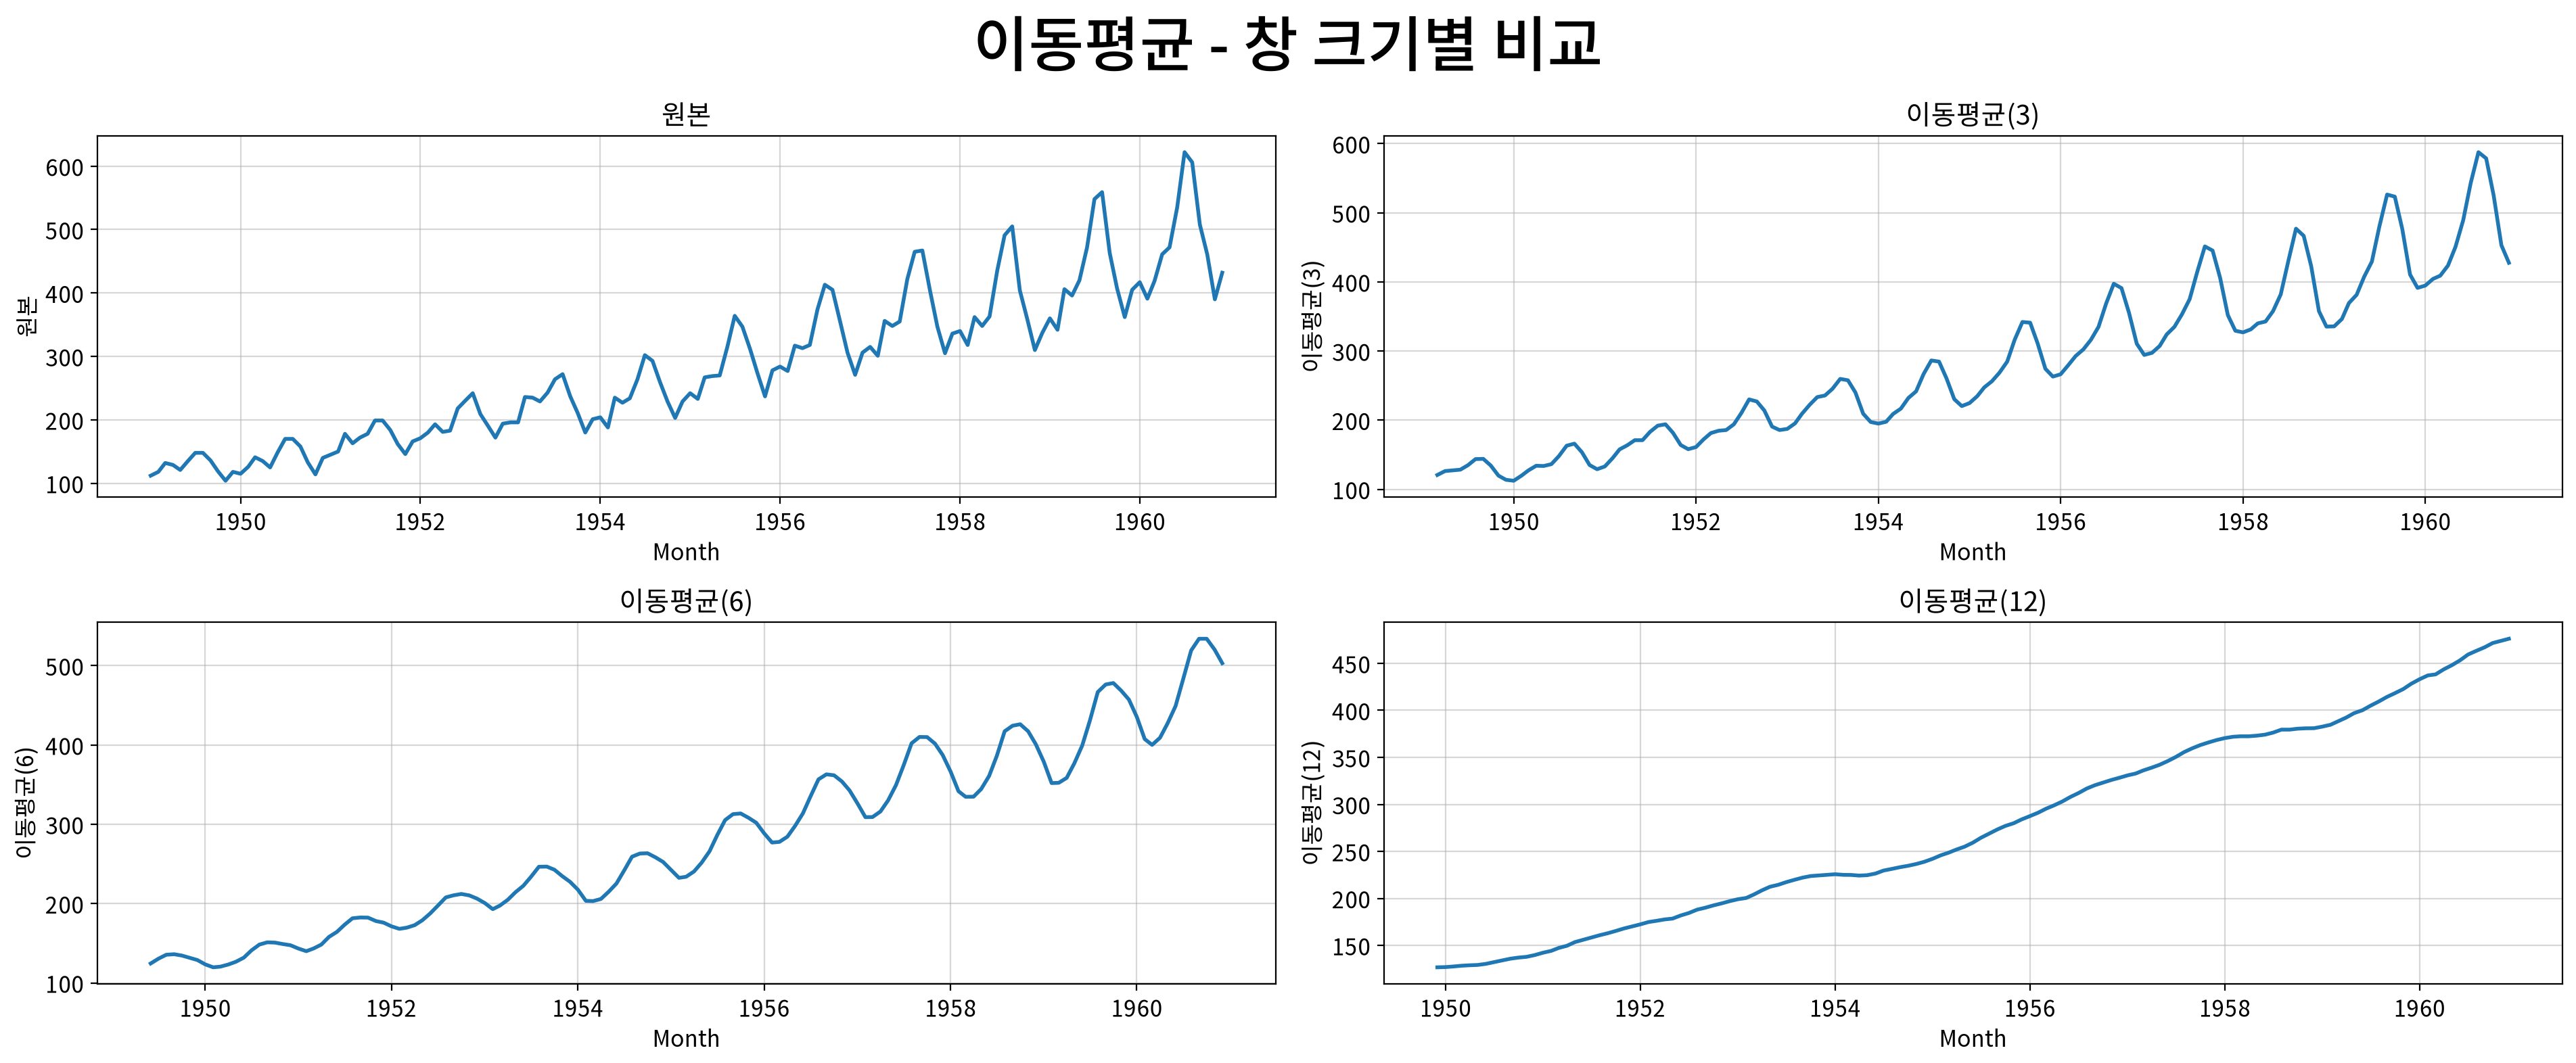

,원본,이동평균(3),이동평균(6),이동평균(12)
Month,,,,
1960-10-01,461,525.000,534.000,471.583
1960-11-01,390,453.000,520.333,473.917
1960-12-01,432,427.667,503.167,476.167


In [58]:
ma = DataFrame({"원본": df["Passengers"]})

for k in (3, 6, 12): 
    ma[f"이동평균({k})"] = df["Passengers"].rolling(k).mean()

# 원본 + 창 3개 = 4칸이므로 2행 2열 격자에 한 칸씩 그린다. 
fig, ax = my_plot.init(rows=2, cols=2, width=960, height=400, 
                       title="이동평균 - 창 크기별 비교")   

for i, col in enumerate(ma.columns):
    my_plot.lineplot(x=ma.index, y=ma[col], ax=ax[i])
    ax[i].set_title(col)

my_plot.show()

ma.tail(3) 

### 결과 확인 
1) 창을 키울 수록 그래프의 봉우리가 지워지고, 창 12에서 계절성이 완전히 사라져 추세만 남는다. 

2) 이동평균(12)은 꾸준히 올라간다. 계절 요동이 지워지고 추세만 남은 것이다. 

### 2. 정상시계열에 적용 실험 -> 차분된 데이터에 적용하기 
1단원에서 확보한 정상 시계열(로그+1차 차분+계절차분) 데이터는 어떤 패턴을 보이는지 확인해본다.



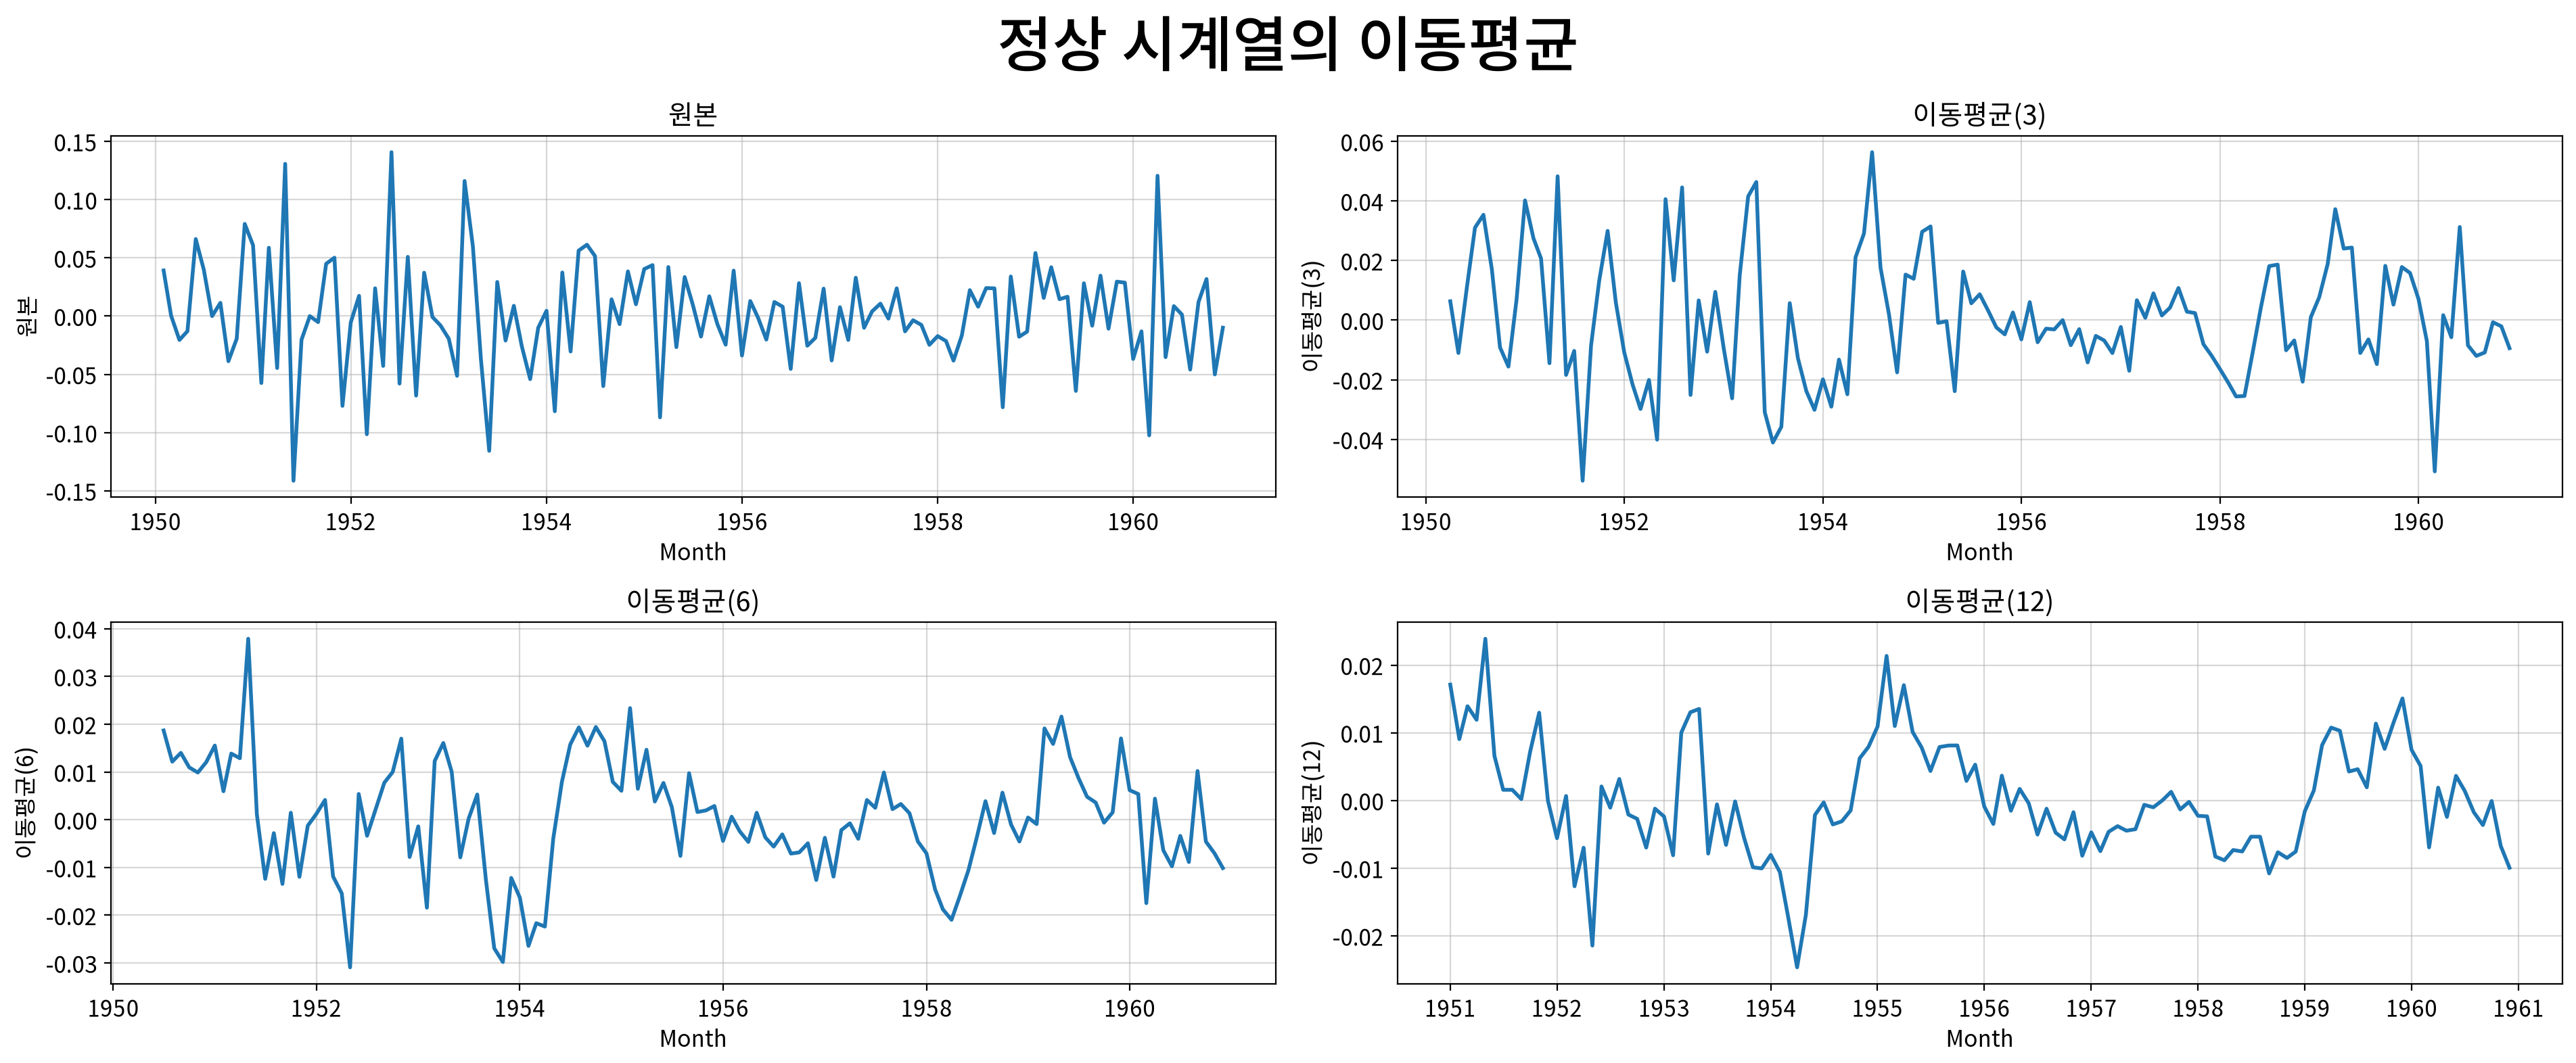

In [59]:
# 1단원에서 결정한 전처리(로그변환 -> 1차 차분 -> 계절차분 )를 한 줄로 적용한다
stationary = my_ts.transform(df, "Passengers", log=True, diff=1, seasonal_diff=1, period=12)

ma_stationary = DataFrame({"원본": stationary})

for k in (3, 6, 12):
    ma_stationary[f"이동평균({k})"] = stationary.rolling(k).mean()

fig, ax = my_plot.init(rows=2,cols=2, width=960, height=400, 
                       title="정상 시계열의 이동평균")

for i, col in enumerate(ma_stationary.columns):
    my_plot.lineplot(x=ma_stationary.index, y=ma_stationary[col], ax=ax[i])
    ax[i].set_title(col)

my_plot.show()

### 결과확인 

평활을 해도 남는 구조가 없다는 것이 "정상 시계열"의 모습이다. 

원본과 달리 이동평균 곡선이 0주변의 수평선에 가깝다. \
창을 키워도 뚜렷한 흐름이 나타나지 않는다. \
-> 더이상 뽑아낼 추세가 없다. 

의미\
평활을 해도 남는 구조가 없다는 것은 잡음만 남았다는 뜻이고, \
그래야 ARIMA 같은 모형이 제대로 작동한다. 

## □ 이동평균의 두 약점을 고친 방법

◎ 가중치가 지수적으로 줄어들어 "지수"평활이다.

### 이동평균의 약점과 지수평활의 해결

| 이동평균의 약점 | 지수평활의 해결 |
|---|---|
| 창 밖의 데이터는 완전히 버린다 | 모든 과거 데이터를 사용한다 |
| 창 안의 데이터를 모두 똑같이 취급한다 | 최근 값에 더 큰 가중치를 준다 |

St = α · yt + (1 − α) · St−1

- **α(평활계수, 0 < α < 1)**는 최근 값을 얼마나 믿을지를 정한다.
- 식을 계속 펼치면 과거 값의 가중치가 α, α(1−α), α(1−α)², … 로 지수적으로 줄어든다. 그래서 "지수"평활이다.

### α의 크기에 따른 성질

| α | 성질 |
|---|---|
| **크다 (1에 가까움)** | 최근 값을 크게 반영 → 민감하게 반응, 잡음도 따라간다 |
| **작다 (0에 가까움)** | 과거를 오래 기억 → 부드럽지만 변화에 느리다 |

> **pandas에서의 지정**
> α 대신 **span**으로 지정하는 것이 편하다.
> α = 2 / (span + 1) 이므로
> **span=12**는 대략 12개 기간을 반영한다는 뜻이 된다.

## □ Pandas 코드 사용시 주의사항

◎ 첫 번째 인자는 span이 아니라 com(중심질량)이다.
- 그래서 반드시 파라미터 이름을 지정해야 한다.

```python
데이터프레임[컬럼명].ewm(span=p).mean()  # 기간 p의 지수가중이동평균
```

| 쓴 것 | 실제 해석 | 실제 평활 |
|---|---|---|
| `ewm(3)` | com = 3 | **span = 7** |
| `ewm(span=3)` | span = 3 | span = 3 |

> pandas의 com은 **α = 1 / (1 + com)** 으로 정의된다.
> 단위 6의 **α = 2 / (span + 1)** 과 같다고 놓으면
> **span = 2 · com + 1** 이다.
> 그래서 **com = 3 은 span = 7** 이 된다.

### ⚠ 함정

변수 이름을 `ewm3`으로 붙여 놓고 `ewm(3)`을 쓰면 실제로는 **span=7짜리 평활**이 된다. 그래프도 결과표도 그럴듯해 보이므로 **끝까지 발견되지 않는다.**

### Pandas 코드 사용시 주의 사항 
첫번째 인자는 span이 아니라 com(중심질량)이다. \
그래서 반드시 파마미터 이름을 지정해야 한다. 

데이터프레임[컬럼명].ewm(span=p).mean() # 기간 p의 지수가중이동평균

pandas의 com은 알파 = 1/(1+com) 으로 정의된다 \
단위 6의 알파 = 2/(span+1) 과 같다고 놓으면\
span = 2* com +1   이다. 
그래서 com =3 은 span = 7 이 된다.

함정\
변수 이름을 ewm3으로 붙여놓고 ewm(3)을 쓰면 실제로는 span=7짜리 평활이 된다. \
그래프도 결과표도 그럴듯해 보이므로 끝까지 발견되지 않는다. 

## #03. 지수 평활법
### 1. 기간을 바꿔가며 관찰하기 

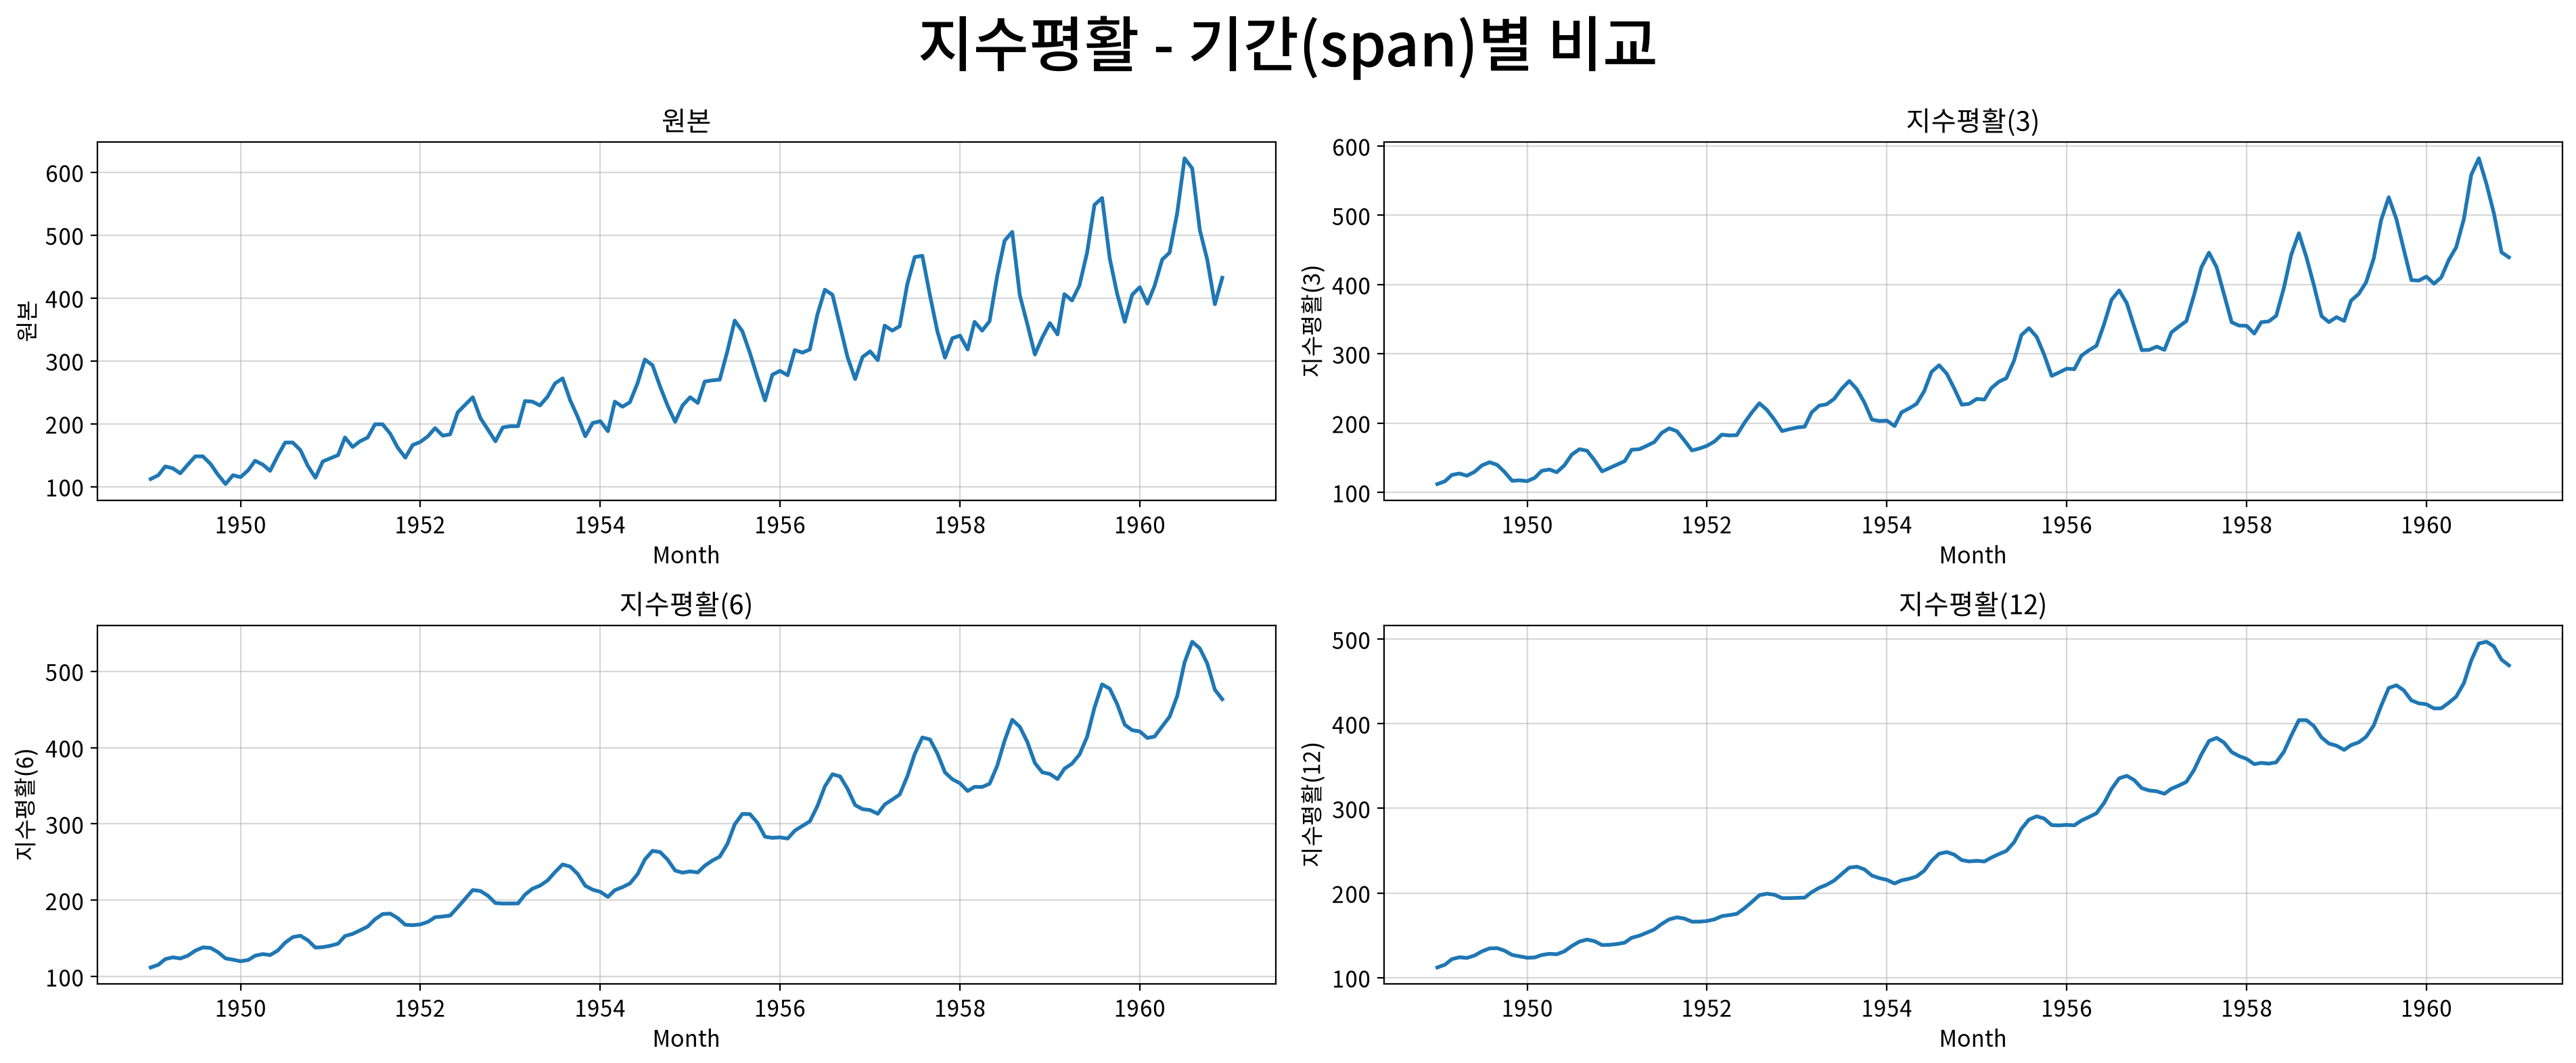

,원본,지수평활(3),지수평활(6),지수평활(12)
Month,,,,
1960-10-01,461,503.024,510.158,491.389
1960-11-01,390,446.512,475.827,475.791
1960-12-01,432,439.256,463.305,469.054


In [60]:
ew = DataFrame({"원본": df["Passengers"]})

for p in (3, 6, 12):
    # 첫 인자는 com(중심질량)이므로 span= 을 반드시 키워드로 명시한다. 
    ew[f"지수평활({p})"] = df["Passengers"].ewm(span=p).mean()

fig, ax = my_plot.init(rows=2, cols=2, width=960, height=400, 
                       title="지수평활 - 기간(span)별 비교")

for i, col in enumerate(ew.columns):
    my_plot.lineplot(x=ew.index, y=ew[col], ax=ax[i])
    ax[i].set_title(col)

my_plot.show()

ew.tail(3)  

### 결과확인 

1) span을 키워도 봉우리가 완전히 사라지지 않는다.\
이것이 이동평균과 결정적으로 다른 점이다. 

span이 커질수록 곡선이 부드러워지는 것은 이동평균과 같다.\
그러나 span=12 에서도 봉우리가 완전히 사라지지 않는다. \
최근 값에 가중치를 주기 때문에 성수기의 흔적이 남는 것이다. 

2) 같은 시점의 이동평균은 상승했지만, \
지수평활은 하락한다. 

원본이 떨어진 것을 따라간 것이다. 

## # 이동평균과 지수평활의 차이점 

## □ 서로 다른 목적

◎ "장기 추세가 뭐지?"와 "지금 상태가 어떻지?"는 다른 질문이다.

### 선택 기준

**"이 데이터의 장기 추세가 뭐지?"**
→ **이동평균** (창 = 계절 주기)

**"지금 상태가 어떻지? 다음 달은?"**
→ **지수평활**

| 비교 항목 | 이동평균 | 지수평활 |
|---|---|---|
| 사용하는 데이터 | 창 안의 k개만 | 전체 과거 |
| 가중치 | 모두 동일 | 최근일수록 크다 |
| 결측치 | 앞 k-1개 발생 | 거의 없음 |
| 계절성 제거 | 창 = 주기면 완전히 제거 | 완전히 제거되지 않음 |
| 변화 반응 속도 | 느리다 | 빠르다 |
| 주 용도 | **추세 추출, 구조 파악** | **단기 예측, 현재 상태 추적** |

## #04. 두 방법은 직접 겹쳐서 비교 
### 1. 원본, 이동평균, 지수평활을 한번에 시각화 

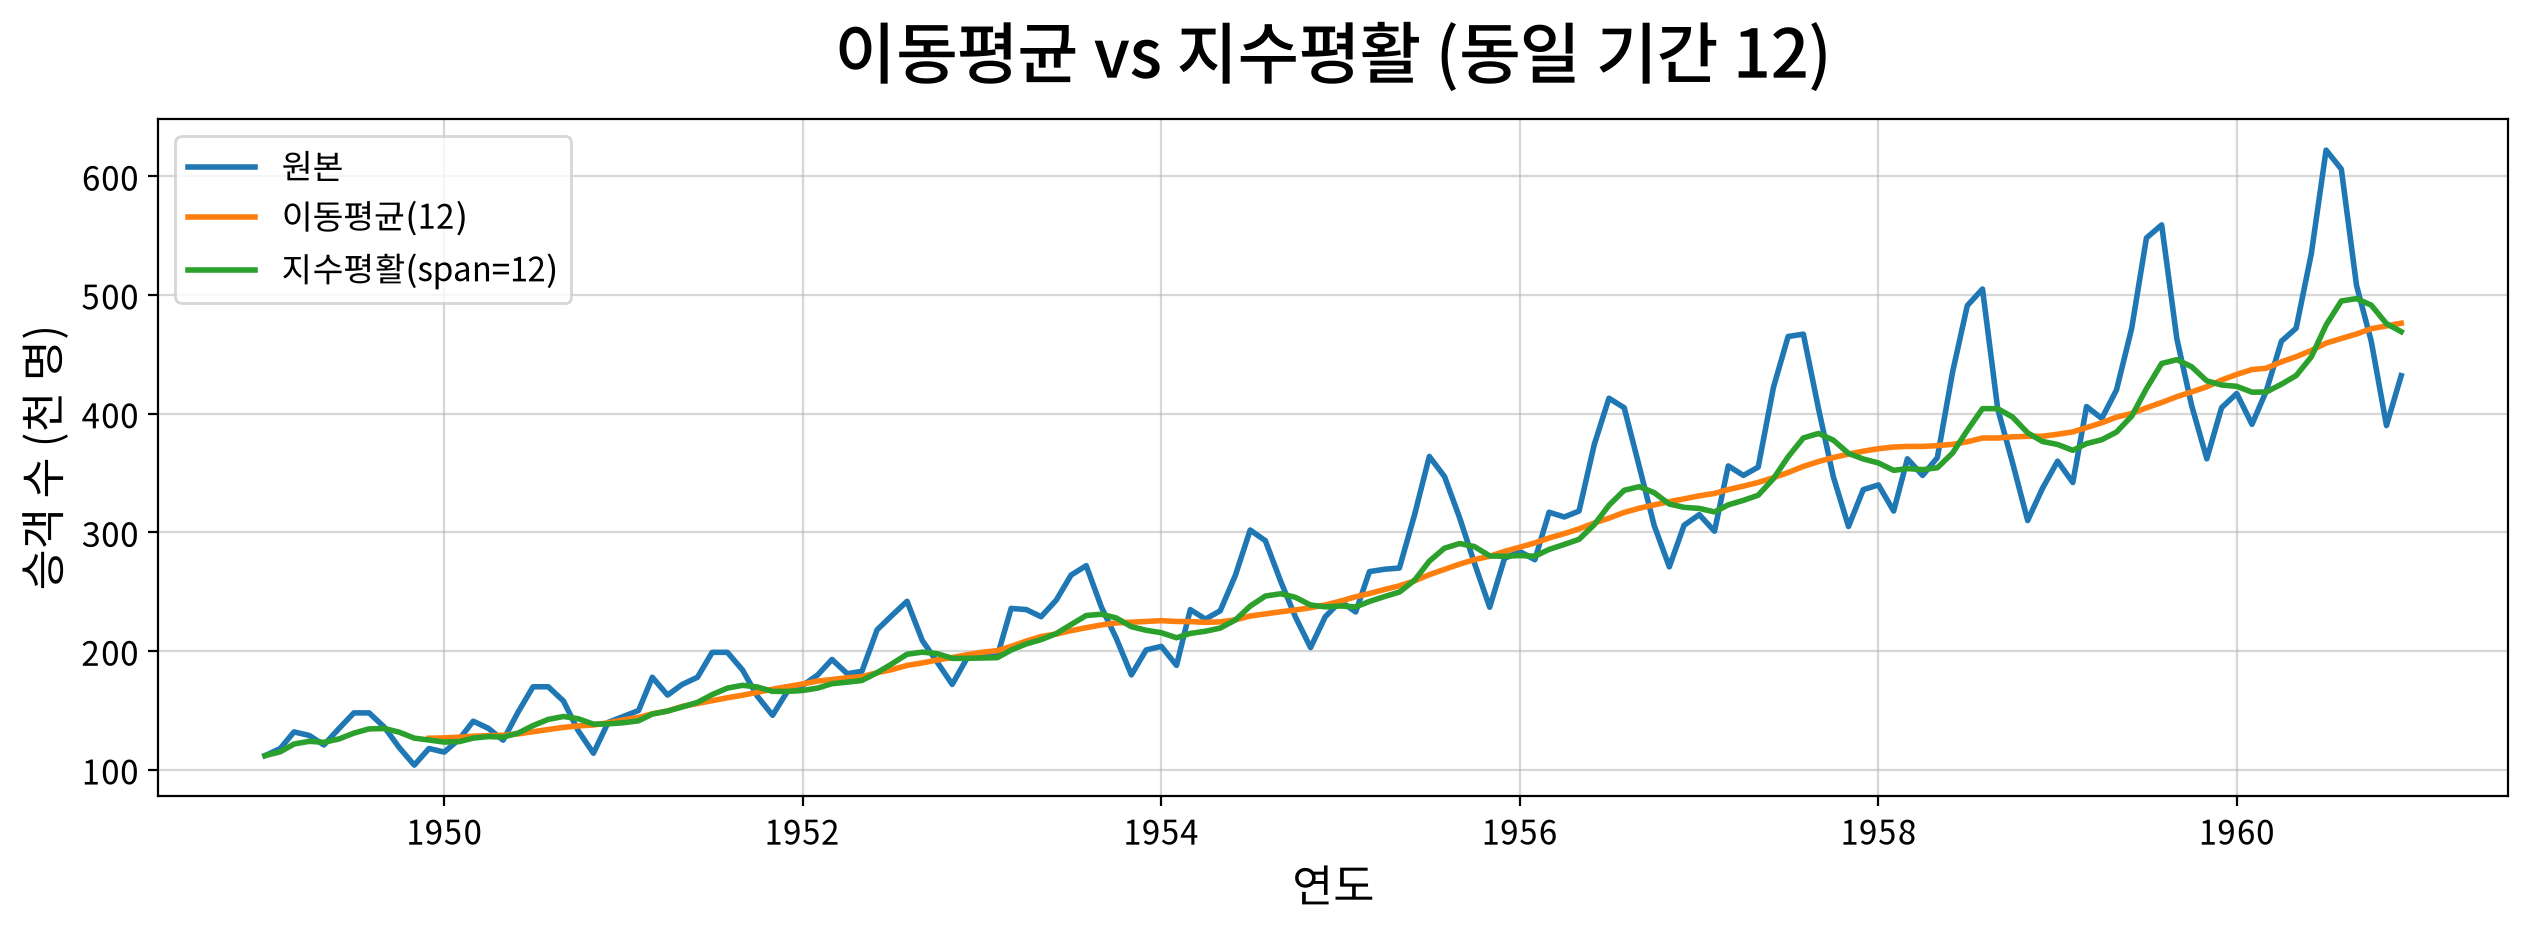

In [61]:
compare = DataFrame({
    "원본": df["Passengers"], 
    "이동평균(12)": df["Passengers"].rolling(12).mean(),
    "지수평활(span=12)": df["Passengers"].ewm(span=12).mean(),
})

fig, ax = my_plot.init(width=1280, height=480,
                       title="이동평균 vs 지수평활 (동일 기간 12)", 
                       xlabel="연도", ylabel="승객 수 (천 명)")

for col in compare.columns:
    my_plot.lineplot(x=compare.index, y=compare[col], label=col, ax=ax)

ax.legend()
my_plot.show()

### 결과 확인 

| 이동평균(12) | 봉우리가 완전히 사라진 매끈한 곡선이다 → **추세 그 자체** |
|---|---|
| 지수평활(span=12) | 봉우리를 따라 출렁이면서 원본을 바짝 뒤쫓는다 → **현재 상태 추적** |
| 지연(lag) | 지수평활은 원본보다 약간 오른쪽으로 밀려 있다. 과거를 반영하기 때문에 생기는 지연이다. |

> 같은 기간(12)을 줬는데도 결과가 이렇게 다르다. "평활 강도"가 아니라 "무엇을 보려는가"로 방법을 고른다.

## # 정리 : 이 단원에서 확인한 것 

## □ 두 평활 기법 비교

| 기법 | 계산 방식 | 쓰는 상황 | 그래프의 모습 |
|---|---|---|---|
| 이동평균 | 창 안의 값을 평균 | 추세를 뽑아낼 때 (창 = 계절 주기) | 매끄러운 추세선 |
| 지수평활 | 최근에 가중치를 준 평균 | 현재 상태 추적, 단기 예측 | 원본을 뒤쫓는 곡선 |

### 이 단원에서 확인한 것

| 항목 | 내용 |
|---|---|
| 계절 주기 | 12개월 (이동평균 창 12에서 계절성이 완전히 사라짐) |
| 추세의 모양 | 꾸준한 우상향, 꺾이는 지점 없음 |
| 정상 시계열의 평활 | 창을 키워도 흐름이 나타나지 않는다 → 더 뽑아낼 추세가 없다 |
| 두 방법의 차이 | 같은 기간(12)을 줘도 이동평균은 봉우리가 사라지고, 지수평활은 봉우리를 따라간다 |

# 2. 시계열 평활 모듈화 

## #07. 모듈화 기능 확인 

### 1. 원본 + 이동평균 + 이동표준편차 시각화 

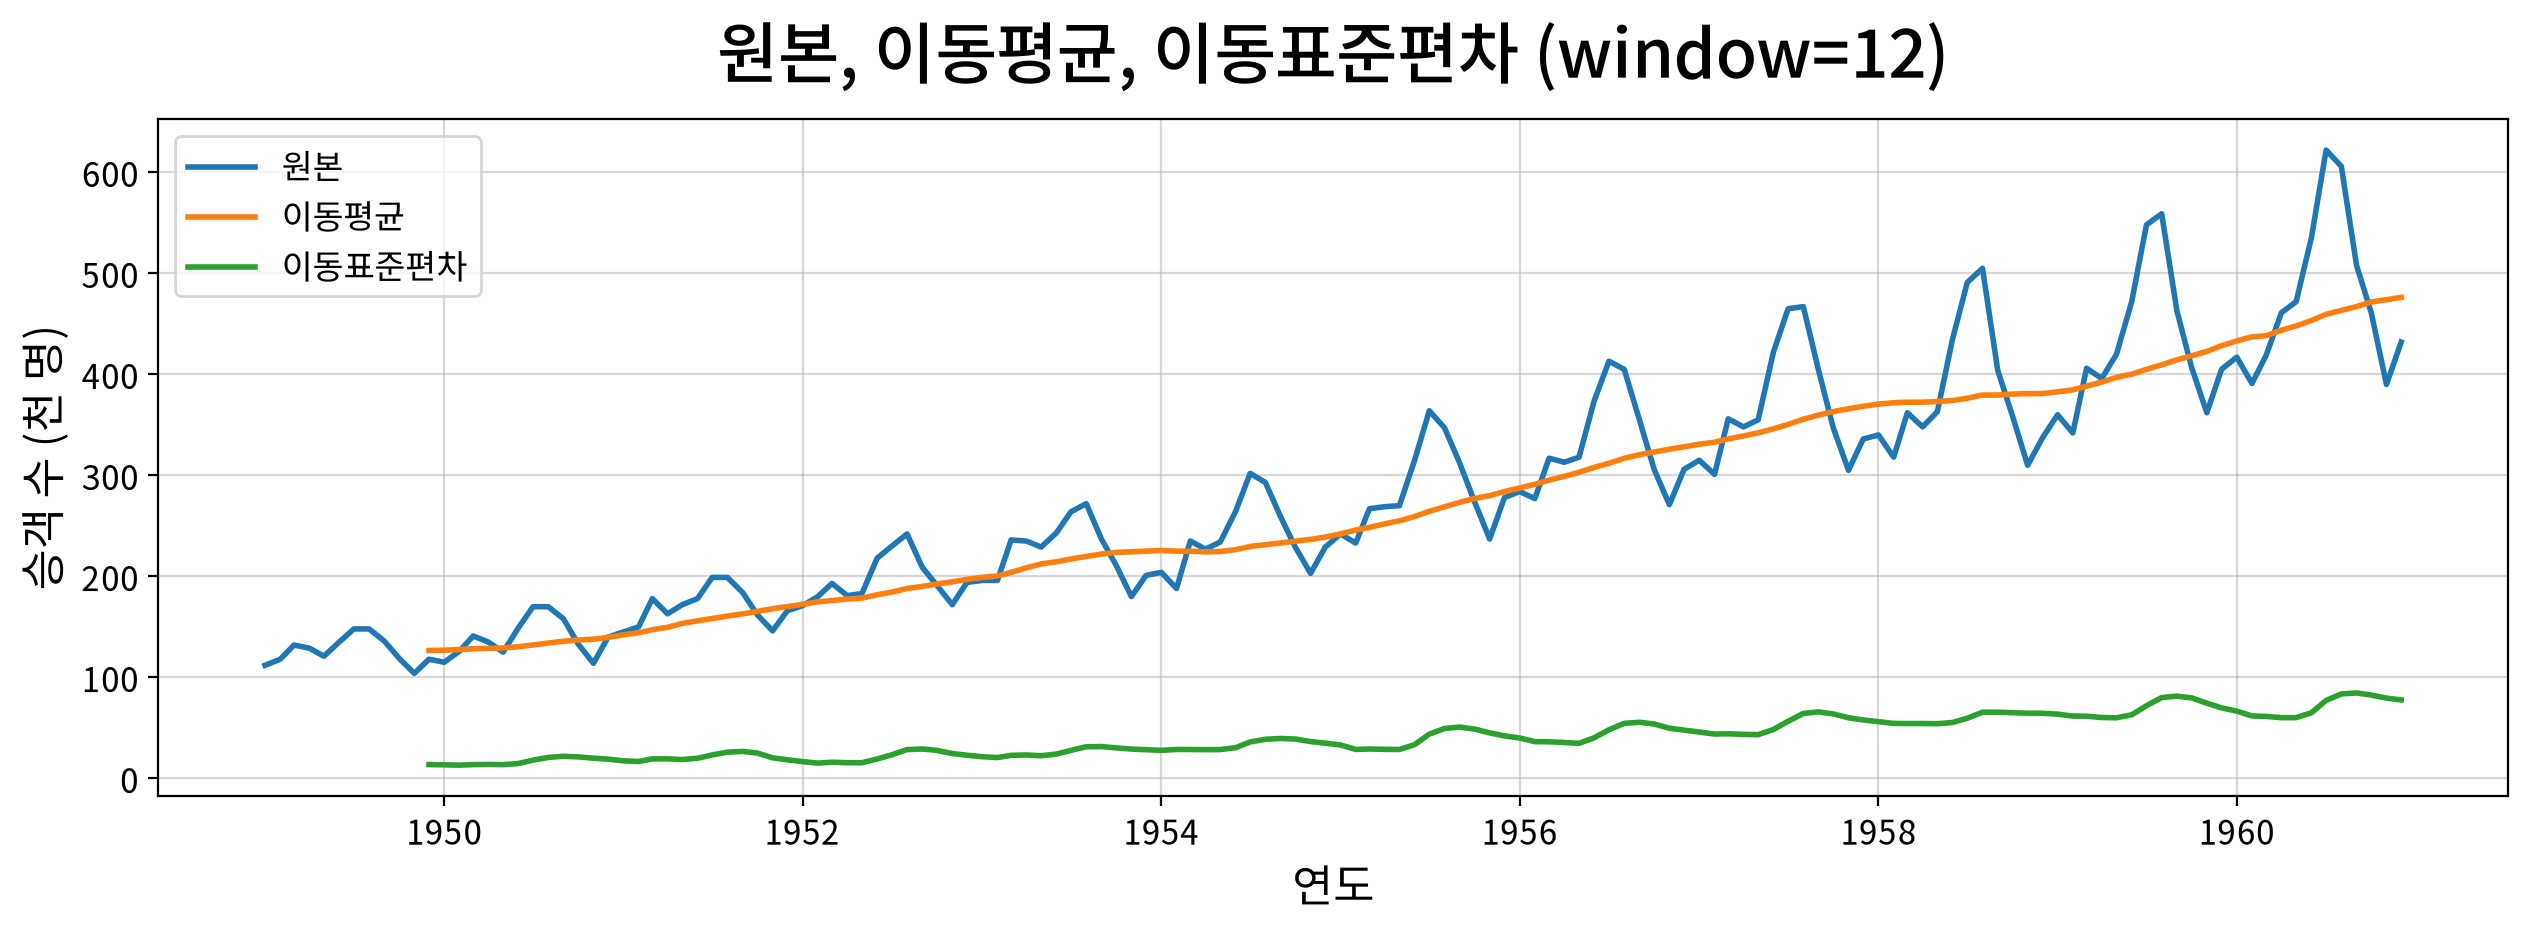

,원본,이동평균,이동표준편차
Month,,,
1960-10-01,461,471.583,82.542
1960-11-01,390,473.917,79.502
1960-12-01,432,476.167,77.737


In [62]:
# 창 크기는 계절 주기(12)로 잡는다. 
rolling = my_ts.plot_rolling(df, 12, "Passengers", 
                             xlabel="연도", ylabel="승객 수 (천 명)")

rolling.tail(3)

### 2. 정상시계열 + 이동평균 + 이동표준편차 시각화 

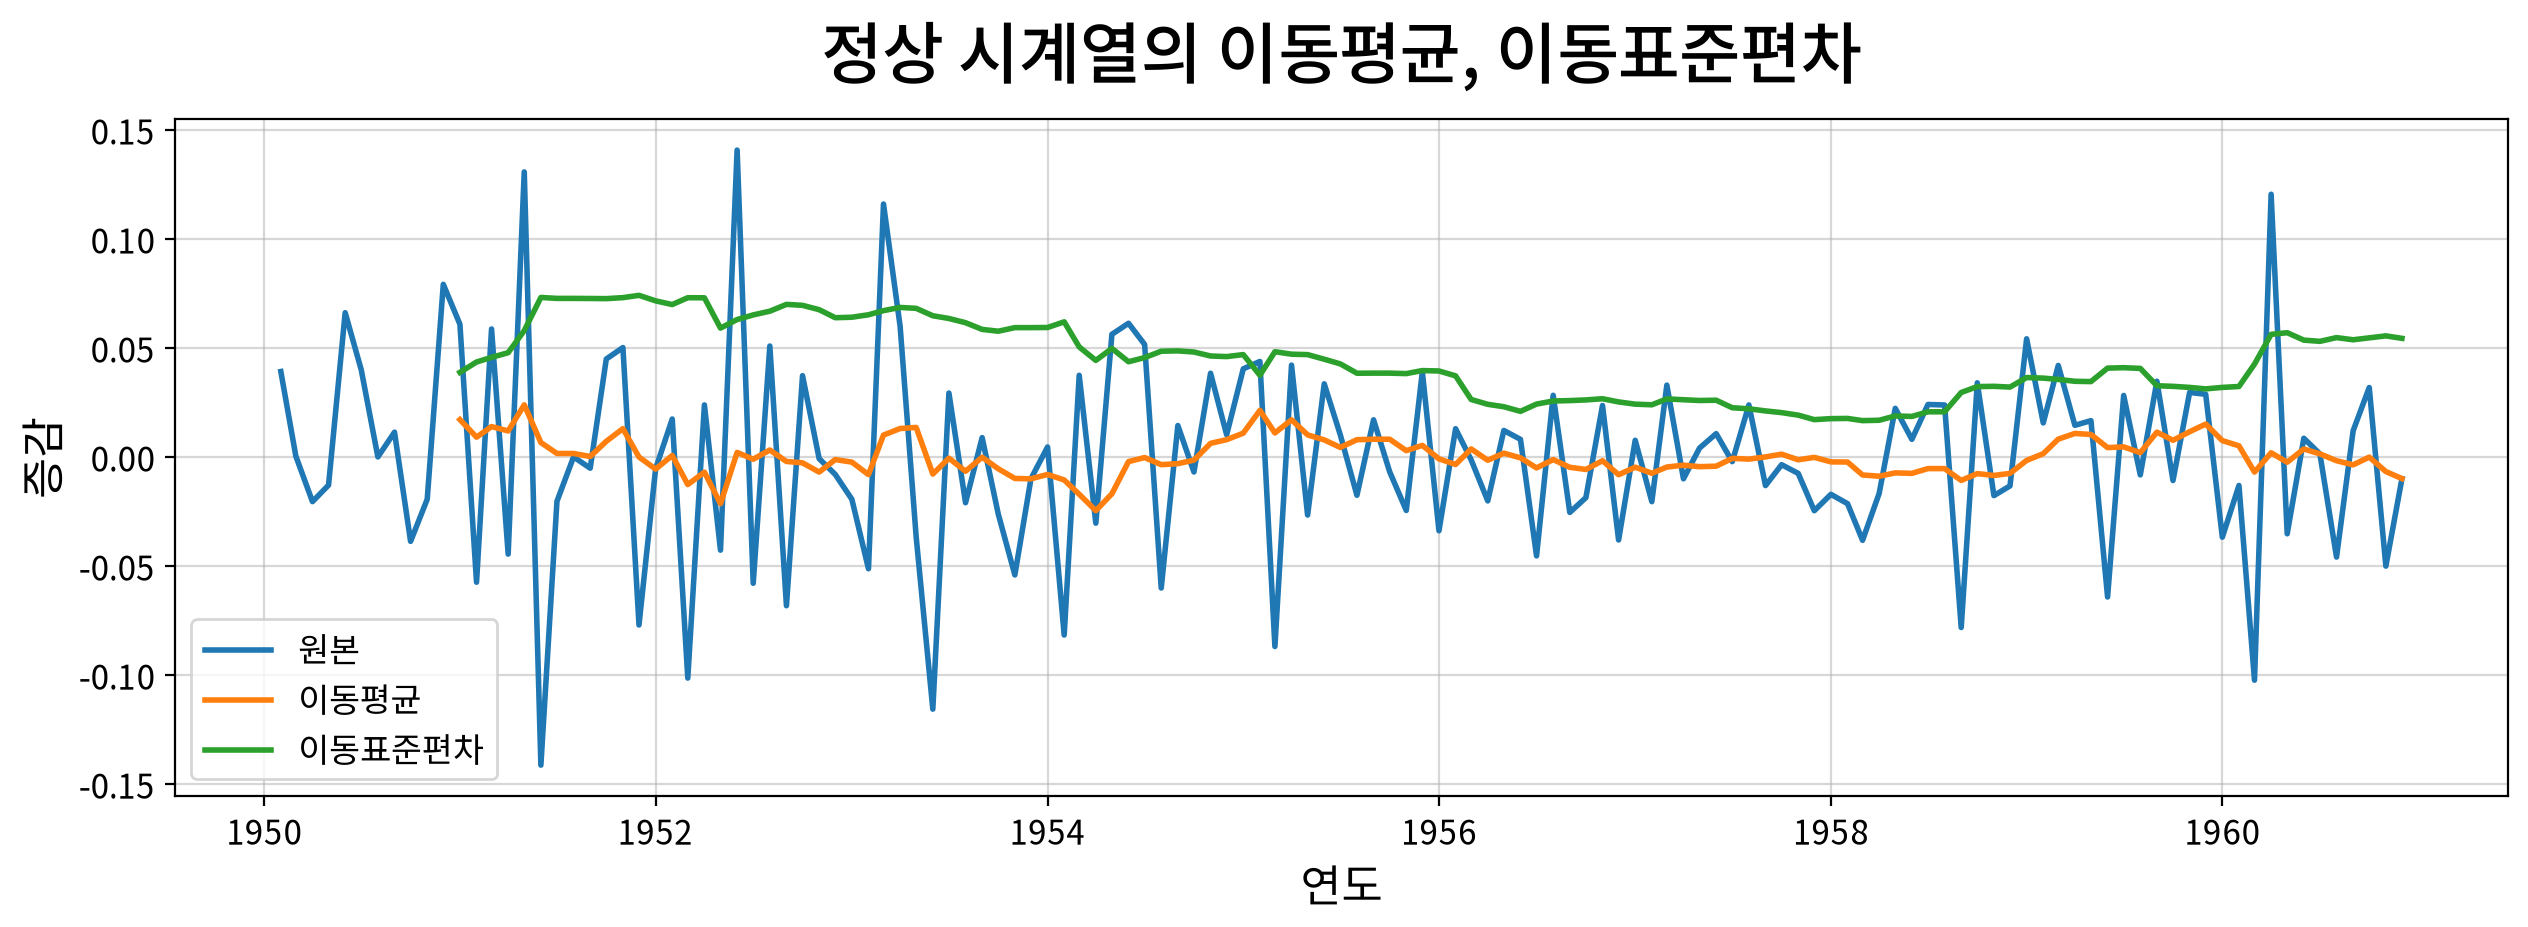

,원본,이동평균,이동표준편차
Month,,,
1960-10-01,0.032,-0.000,0.055
1960-11-01,-0.050,-0.007,0.056
1960-12-01,-0.010,-0.010,0.054


In [63]:
# 같은 그림을 정상 시계열에도 그려 비교한다 
rolling_stationary = my_ts.plot_rolling(stationary, 12, 
                                        title="정상 시계열의 이동평균, 이동표준편차",
                                        xlabel="연도", ylabel="증감")

rolling_stationary.tail(3)

### 3. 격자 형태로 이동평균 창 크기별 비교 

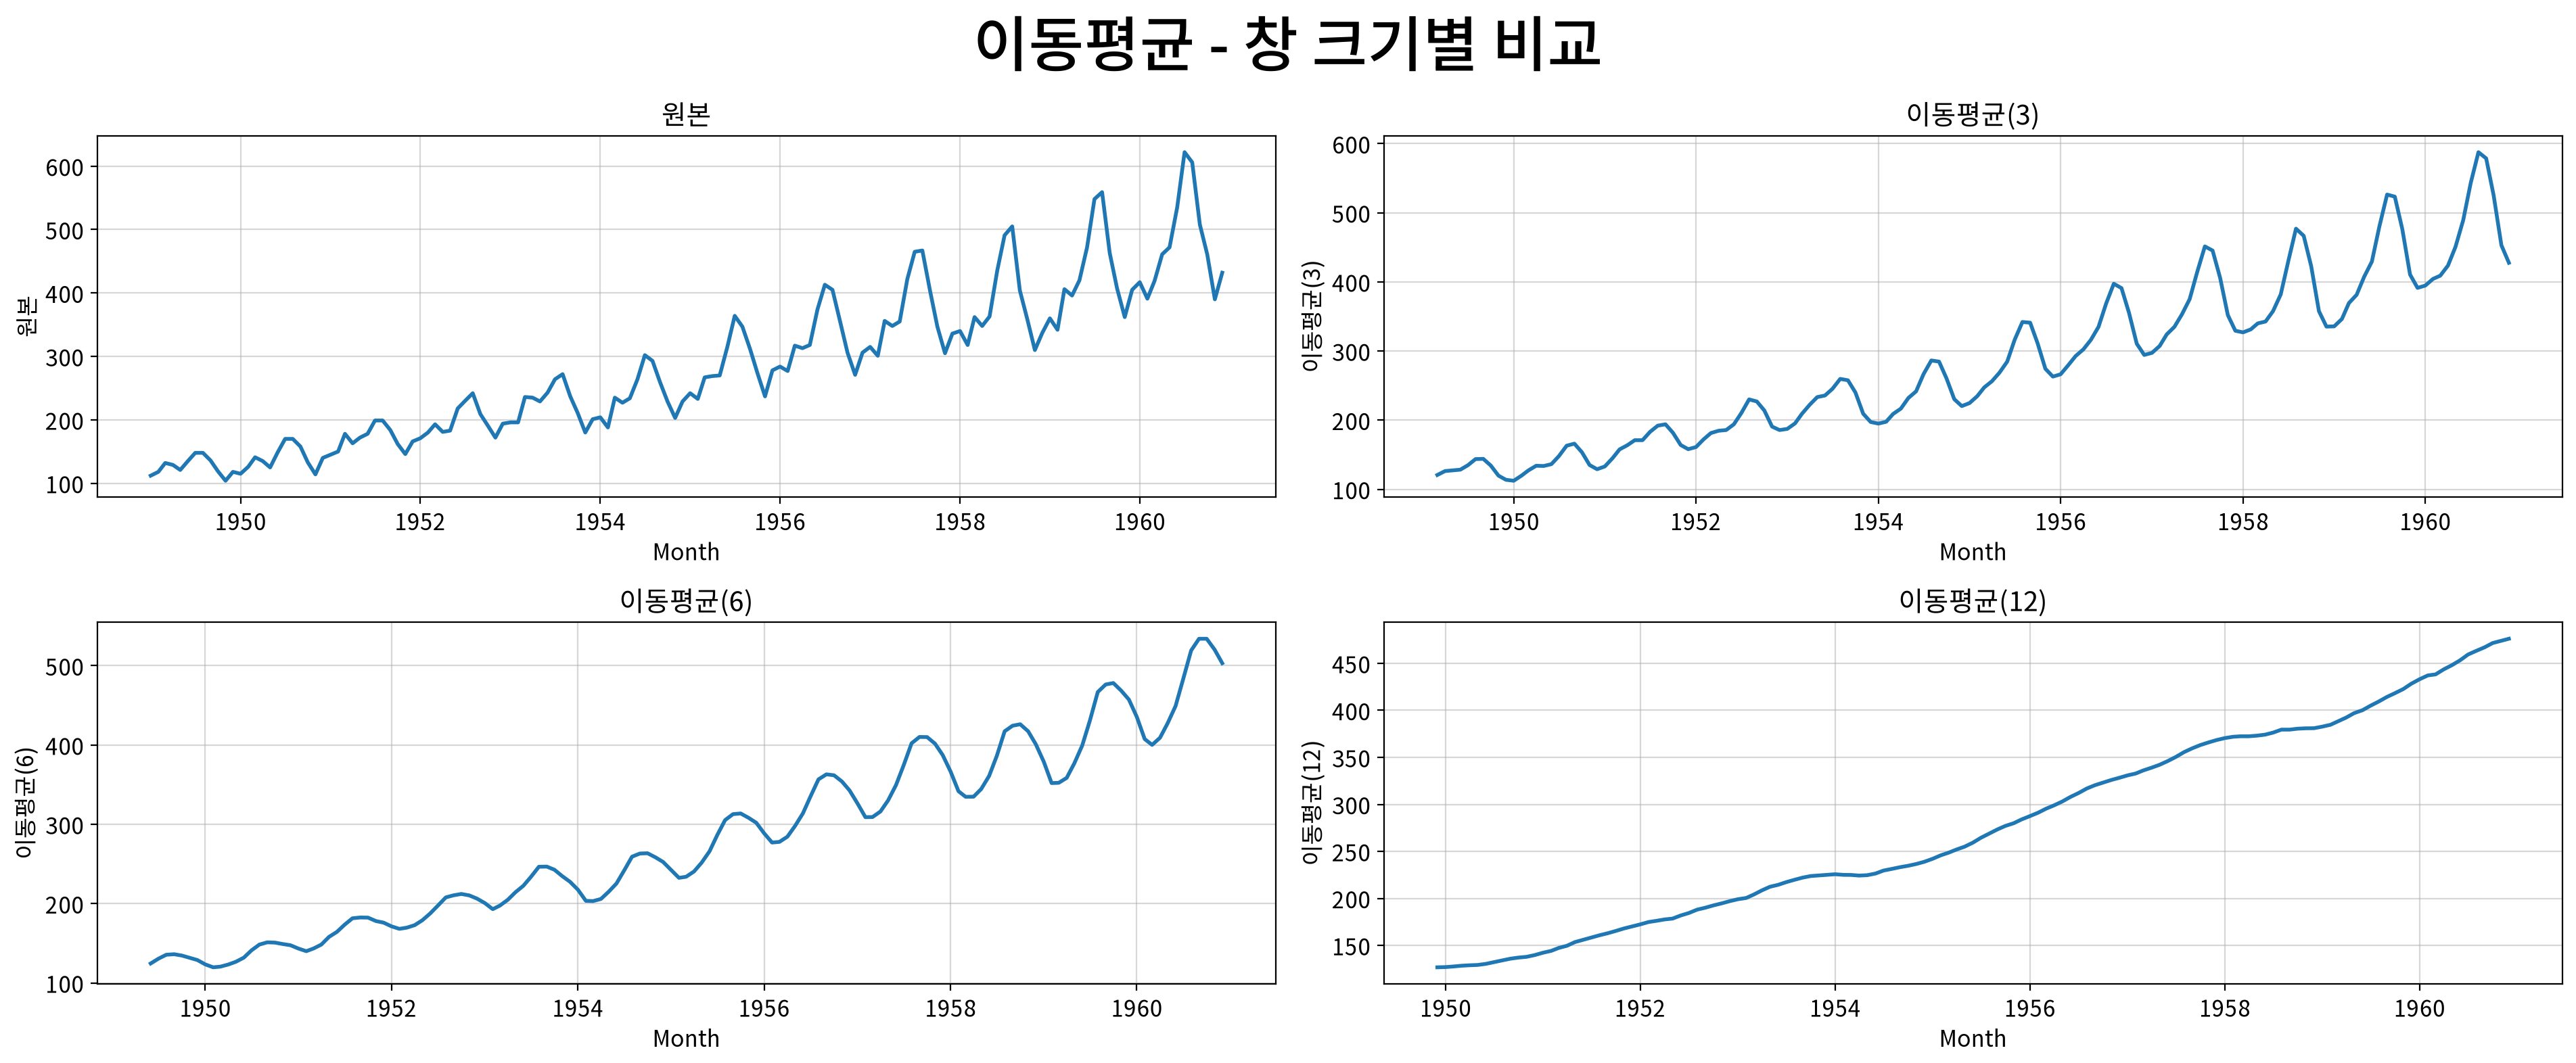

,원본,이동평균(3),이동평균(6),이동평균(12)
Month,,,,
1949-01-01,112,NaN,NaN,NaN
1949-02-01,118,NaN,NaN,NaN
1949-03-01,132,120.667,NaN,NaN
1949-04-01,129,126.333,NaN,NaN
1949-05-01,121,127.333,NaN,NaN
...,...,...,...,...
1960-08-01,606,587.667,519.167,463.333
1960-09-01,508,578.667,534.000,467.083
1960-10-01,461,525.000,534.000,471.583


In [64]:
# 이동평균 창 크기별 비교 
ma_result = my_ts.compare_smoothing(df, (3, 6, 12), "Passengers", method="ma",
                                    title="이동평균 - 창 크기별 비교")

ma_result

### 4. 격자 형태로 지수평활 span별 비교 

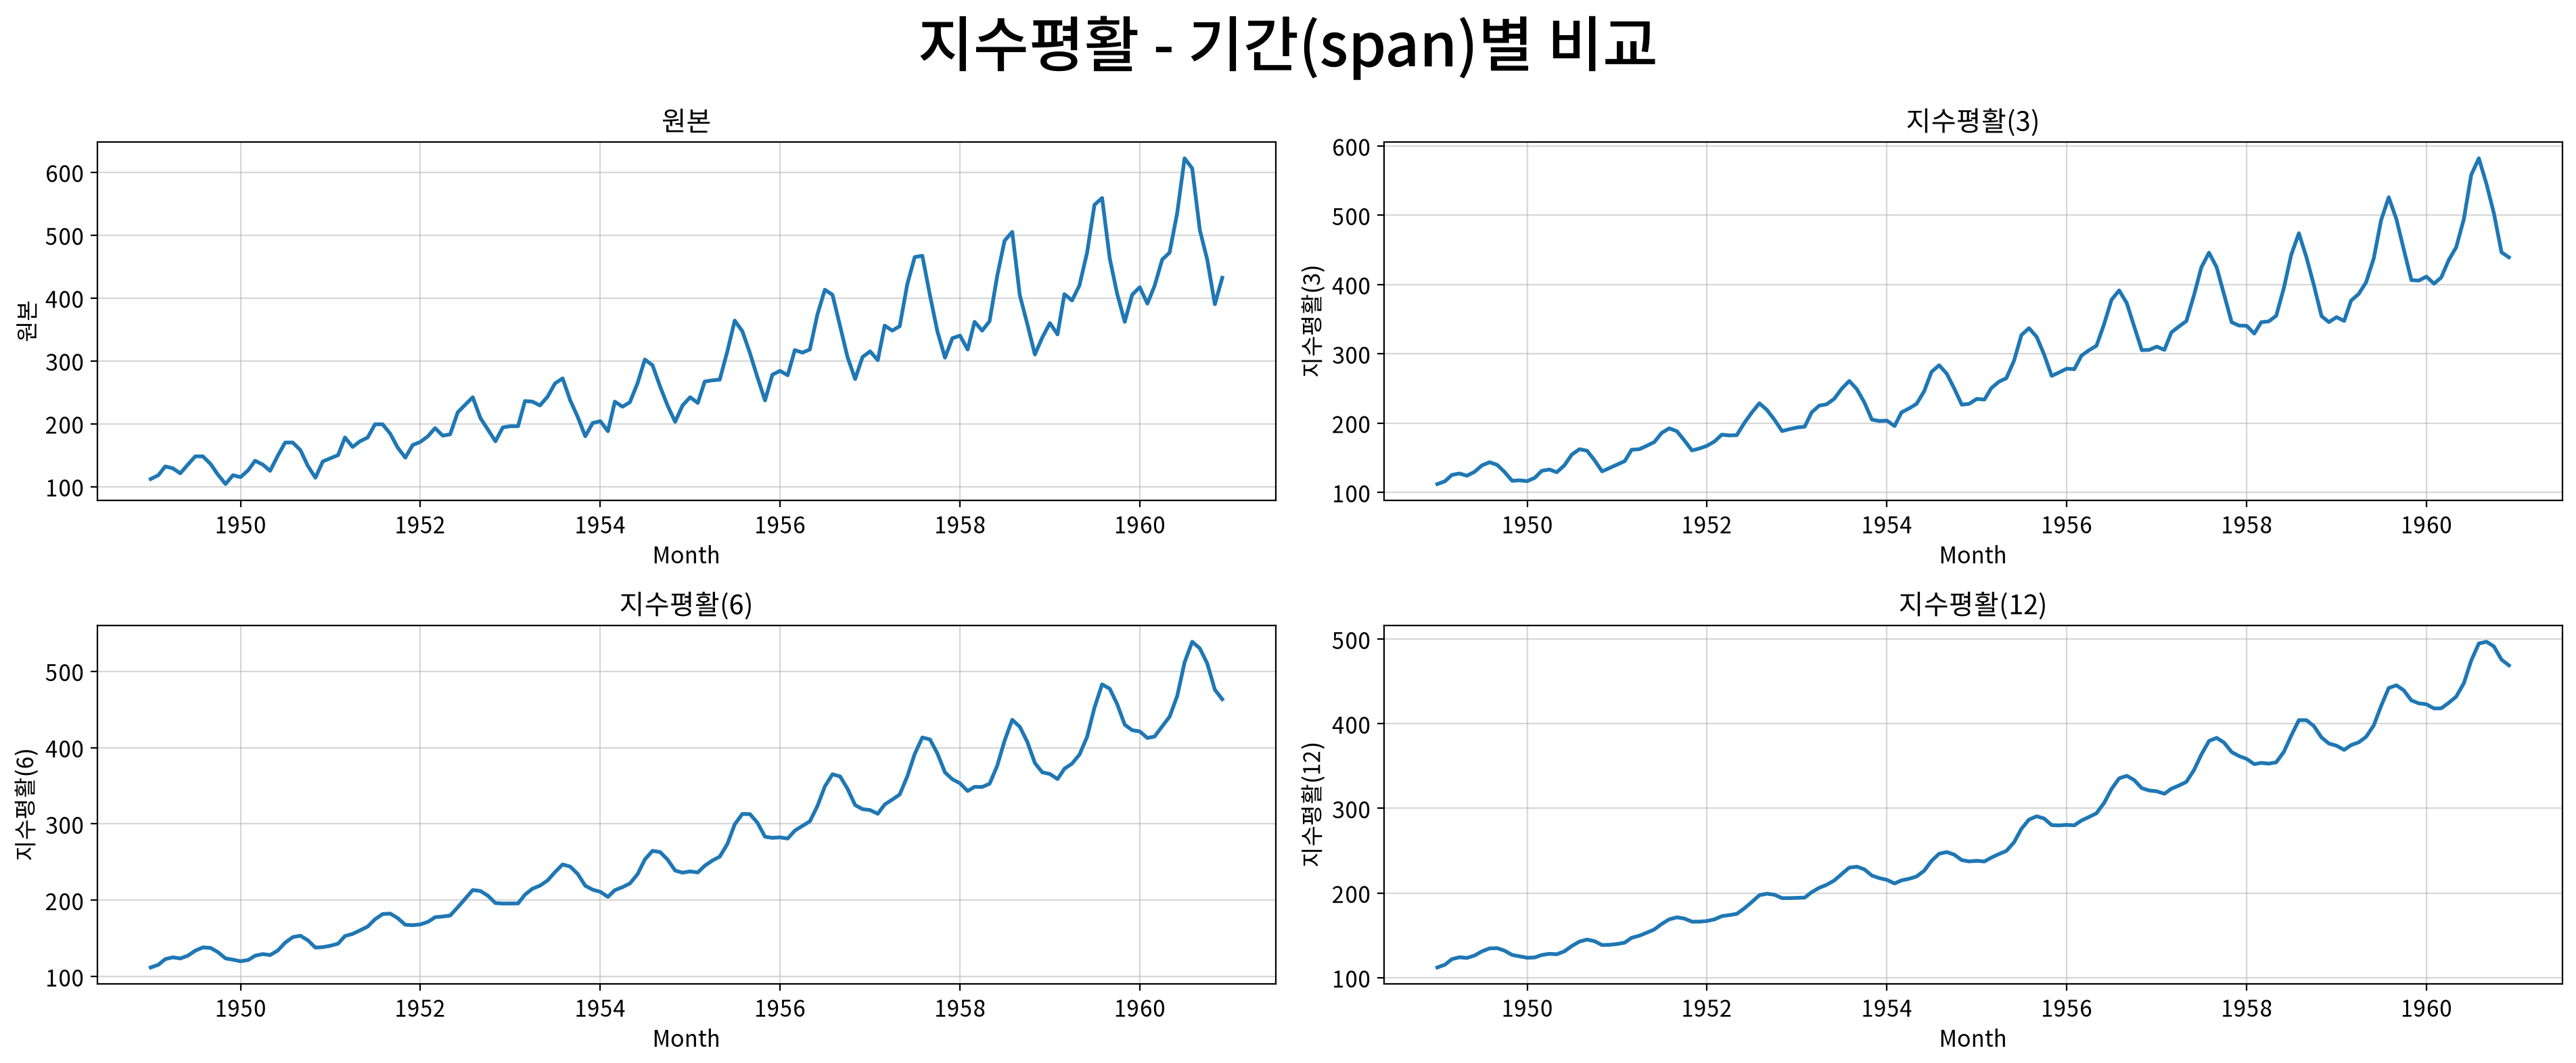

,원본,지수평활(3),지수평활(6),지수평활(12)
Month,,,,
1949-01-01,112,112.000,112.000,112.000
1949-02-01,118,116.000,115.500,115.250
1949-03-01,132,125.143,122.917,121.788
1949-04-01,129,127.200,125.267,124.064
1949-05-01,121,124.000,123.769,123.232
...,...,...,...,...
1960-08-01,606,582.096,538.549,494.899
1960-09-01,508,545.048,529.821,496.914
1960-10-01,461,503.024,510.158,491.389


In [65]:
ewm_result = my_ts.compare_smoothing(df, (3, 6, 12), "Passengers", method="ewm", 
                                     title="지수평활 - 기간(span)별 비교")

ewm_result

### 5. 같은 기간 12로 두 방법을 한 축에 겹쳐 비교 

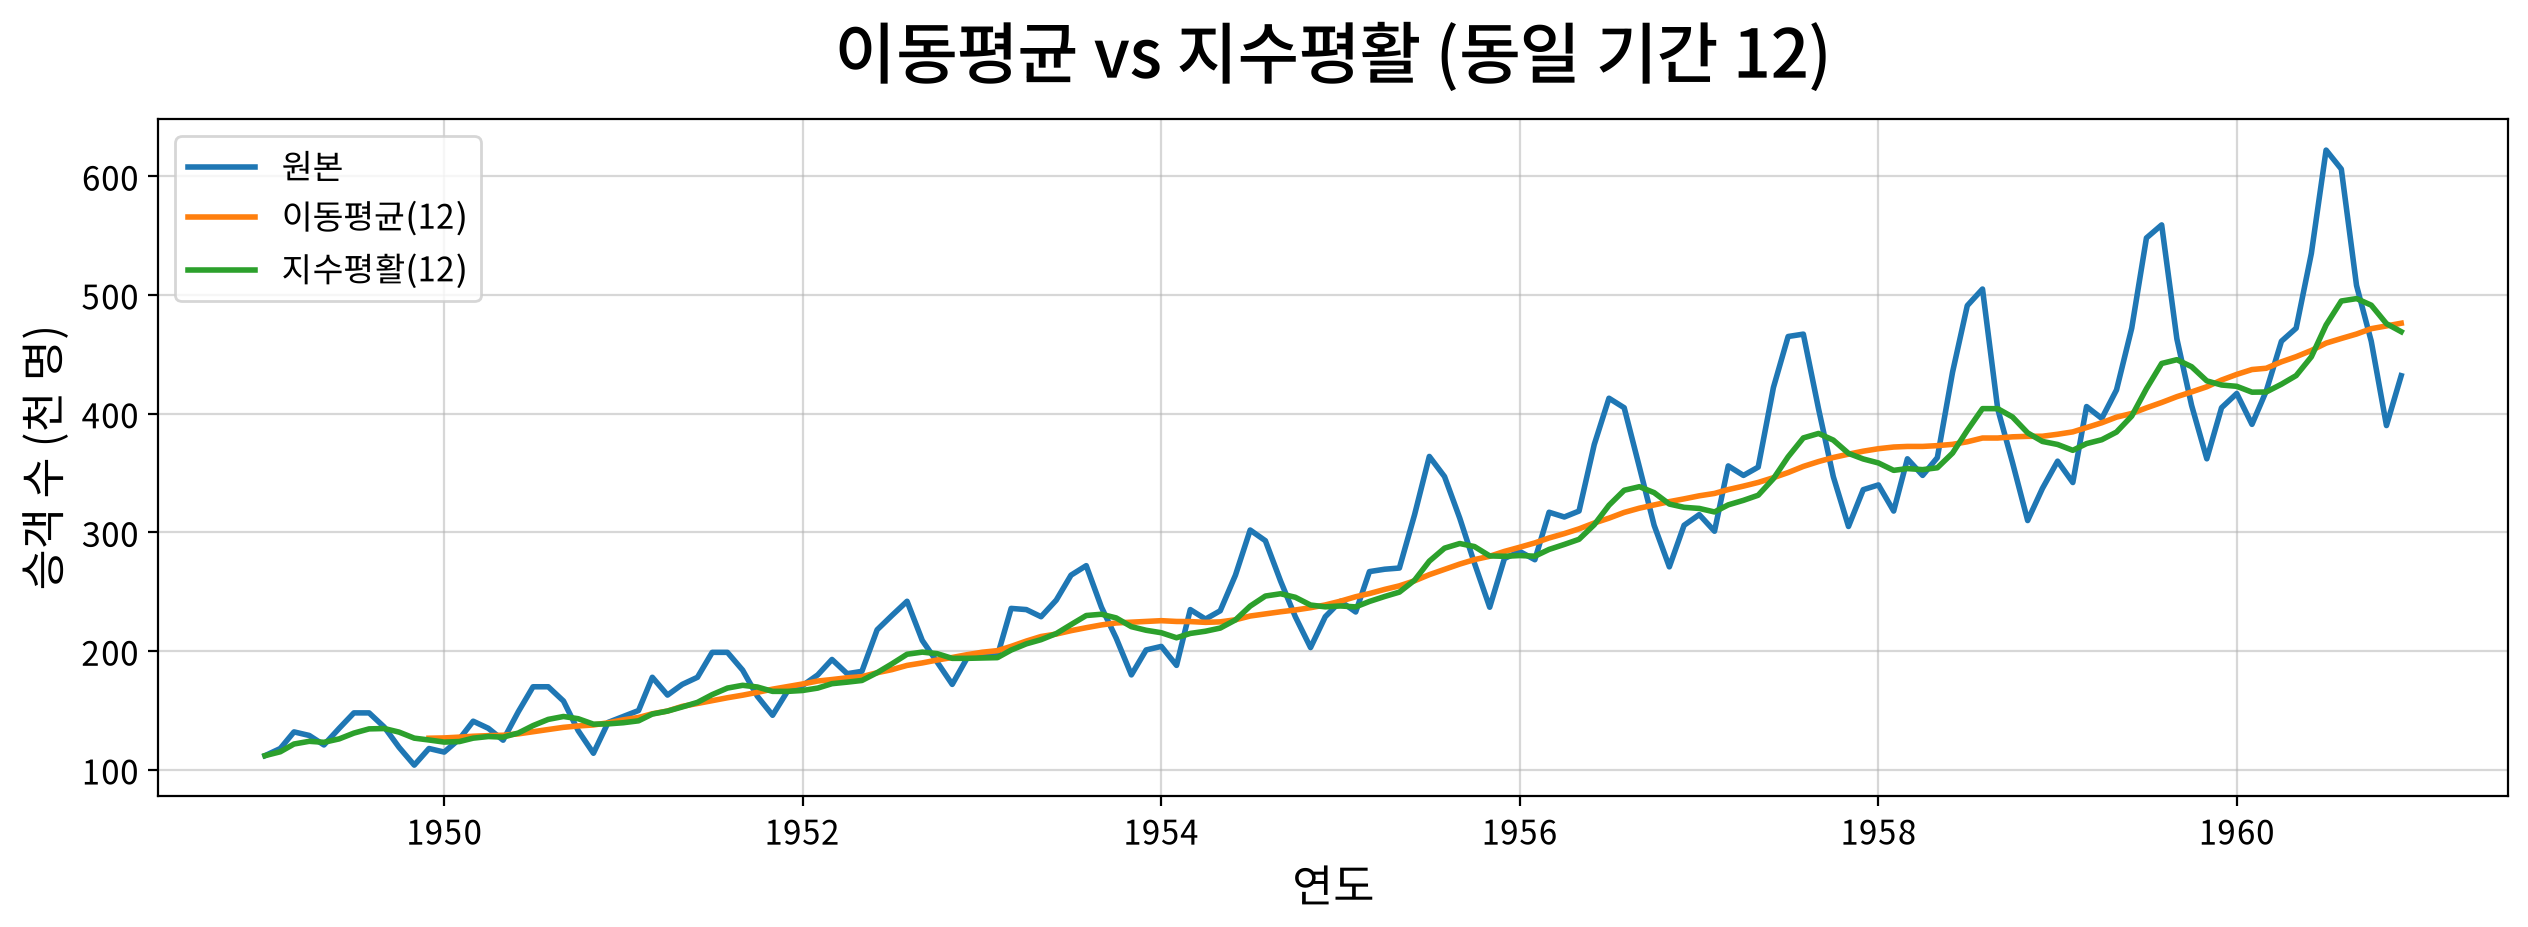

,원본,이동평균(12),지수평활(12)
Month,,,
1949-01-01,112,NaN,112.000
1949-02-01,118,NaN,115.250
1949-03-01,132,NaN,121.788
1949-04-01,129,NaN,124.064
1949-05-01,121,NaN,123.232
...,...,...,...
1960-08-01,606,463.333,494.899
1960-09-01,508,467.083,496.914
1960-10-01,461,471.583,491.389


In [66]:
both_result = my_ts.compare_smoothing(df, [12], "Passengers", 
                                      method="both", overlay=True, 
                                      title="이동평균 vs 지수평활 (동일 기간 12)", 
                                      xlabel="연도", ylabel="승객 수 (천 명)",
                                      width=1280, height=480)

both_result

## # 연습문제 서울 월평균 기온의 데이터 평활 수행 

# [LAB-11] 6. [연습문제] 서울 월평균 기온의 평활

> **문제**
>
> `temperatures_seoul` 데이터는 1973년 7월 ~ 2023년 8월까지 서울의 월평균 기온이다.
> 계절 요동이 지배적이어서 원본 그래프로는 장기 변화를 읽을 수 없다.
> 평활로 계절 요동을 걷어내고 **장기 추세를 드러내시오.**
>
> 1. 창 크기 **3 · 6 · 12 · 24** 를 비교해 **어떤 창을 써야 하는지와 이유**를 답하시오.
> 2. **이동평균과 지수평활** 중 적합한 것을 고르고 **이유**를 답하시오.
> 3. 평활로 드러난 **50년간의 기온 변화**를 답하시오.

## #01. 준비작업

In [67]:
from jussam import load_data
from helpers import *

In [68]:
origin = load_data('temperatures_seoul')

# freq="MS" 로 매월 1일 간격임을 명시해야 창 크기 12가 "1년"을 뜻하게 된다
df = my_ts.set_index(origin, "날짜", freq="MS")

print(f"기간: {df.index[0]:%Y-%m} ~ {df.index[-1]:%Y-%m} | {len(df)}개월 | 간격 {df.index.freqstr}")
df.head(3)

📚 1973년 1월부터 2023년 8월까지 서울의 월평균 기온 데이터 (출처: 기상청)
기간: 1973-07 ~ 2023-08 | 602개월 | 간격 MS


,평균기온(℃)
날짜,
1973-07-01,26.816
1973-08-01,25.884
1973-09-01,20.323


## #02. 원본 확인

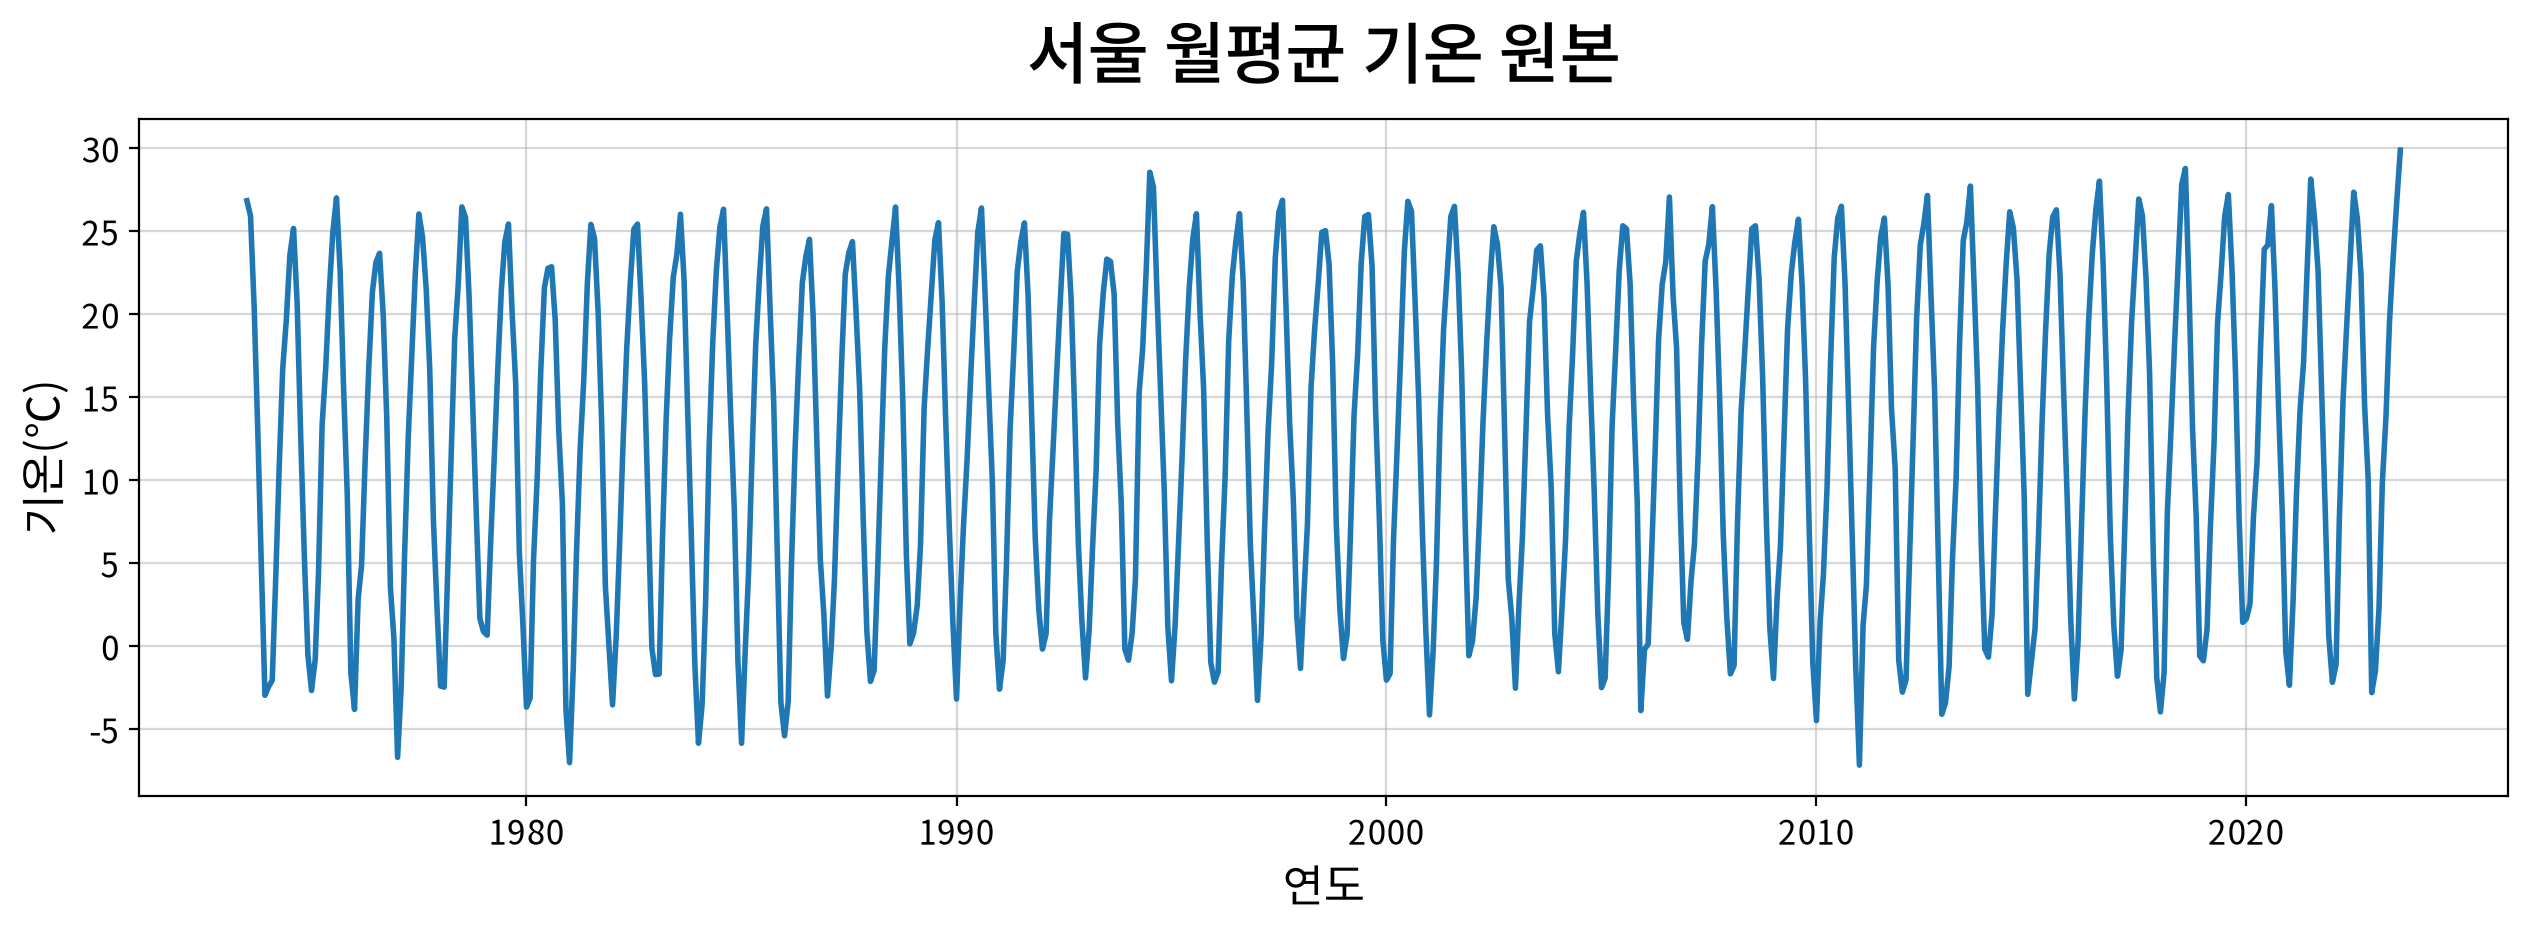

In [69]:
my_plot.lineplot(data=df, x=df.index, y="평균기온(℃)",
                 title="서울 월평균 기온 원본",
                 xlabel="연도", ylabel="기온(℃)",
                 width=1280, height=480)

매년 **−7℃ ~ +30℃** 를 오르내리는 요동이 반복된다. 이 크기에 묻혀 **장기 변화가 보이지 않는다.**

## #03. 창 크기 비교

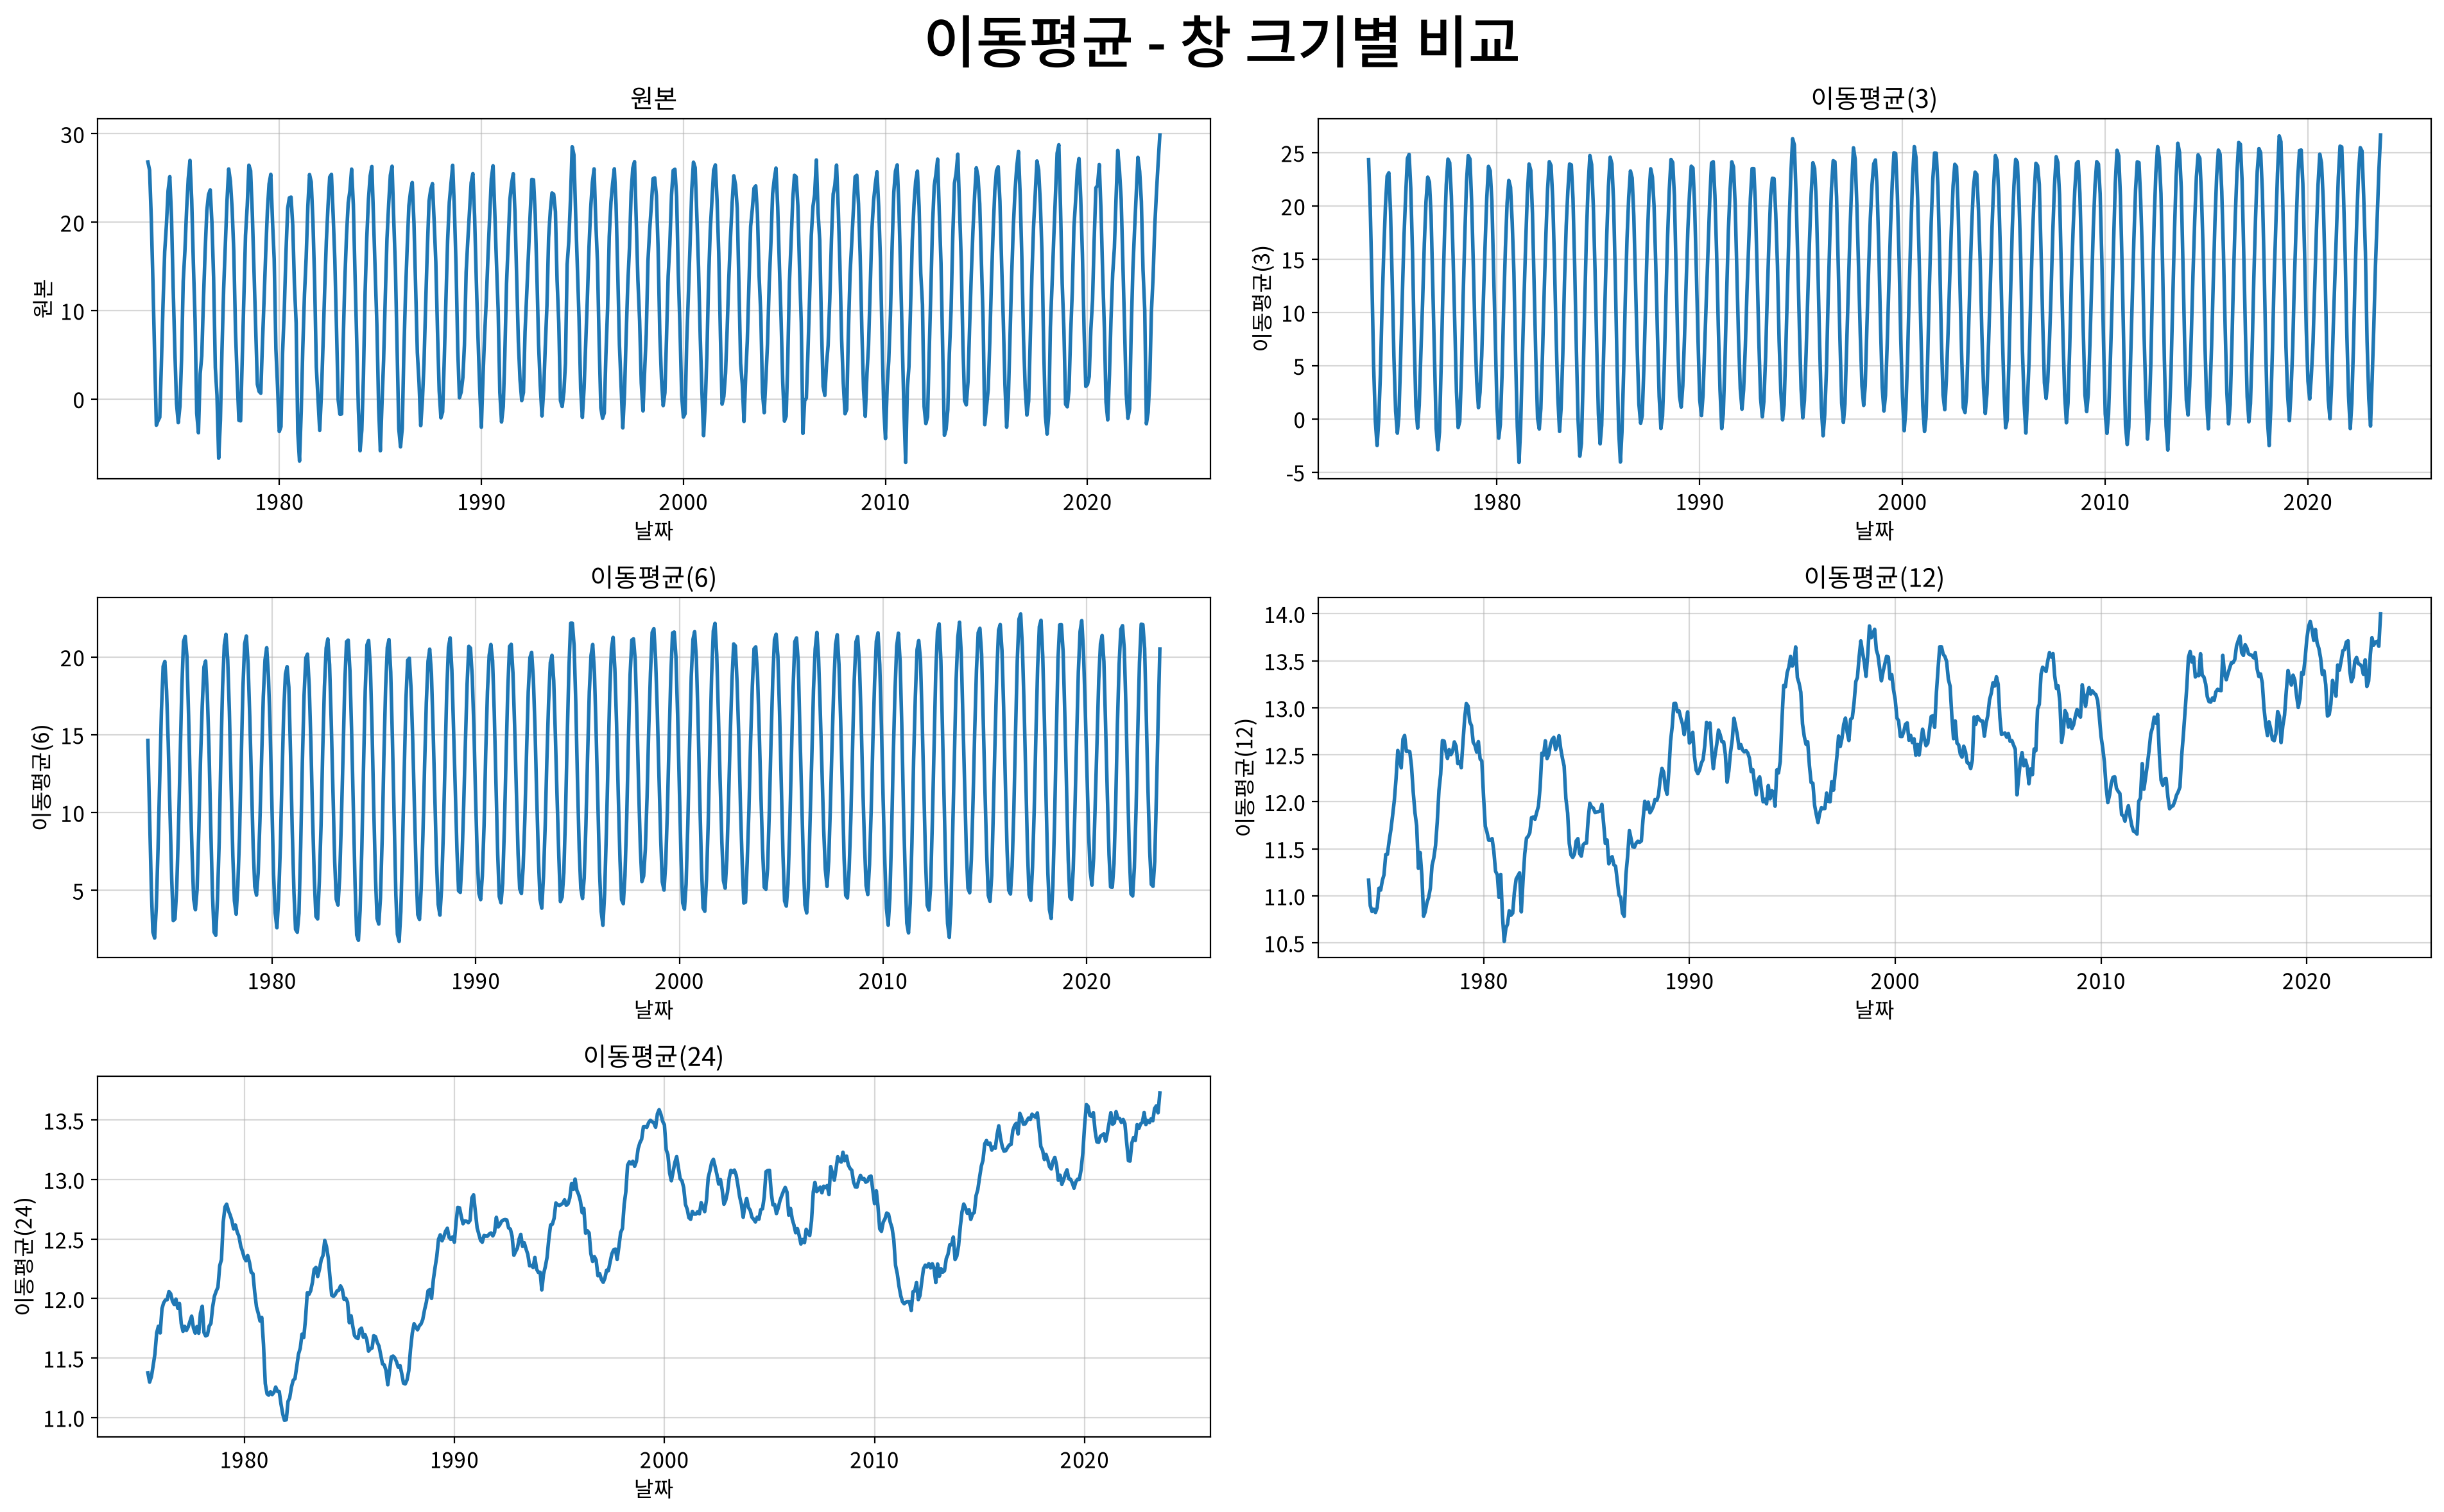

In [70]:
ma = my_ts.compare_smoothing(df, (3, 6, 12, 24), "평균기온(℃)", method="ma",
                             title="이동평균 - 창 크기별 비교",
                             width=960, height=400)

In [71]:
# 반환된 표의 각 열이 얼마나 평평해졌는지 표준편차로 잰다
ma.std().round(3).to_frame("표준편차")

,표준편차
원본,9.932
이동평균(3),8.970
이동평균(6),6.332
이동평균(12),0.745
이동평균(24),0.627


#### 💡 인사이트

| 창 | 표준편차 | 원본 대비 |
|---|---|---|
| 원본 | 9.932 | 100% |
| 3 | 8.970 | 90.3% |
| 6 | 6.332 | 63.8% |
| **12** | **0.745** | **7.5%** |
| 24 | 0.627 | 6.3% |

★ **창을 계절 주기와 같게(12) 잡아야 여름 +15℃와 겨울 −15℃가 상쇄된다.**
창 6은 반년치만 섞이므로 63.8%가 그대로 남는다.

창 12에서 남은 7.5%는 계절성이 아니라 **찾던 장기 추세**다.
창 24도 계절성은 지우지만 양 끝 결측이 늘어난다 → **가장 작은 창**을 쓴다.

## #04. 이동평균 vs 지수평활

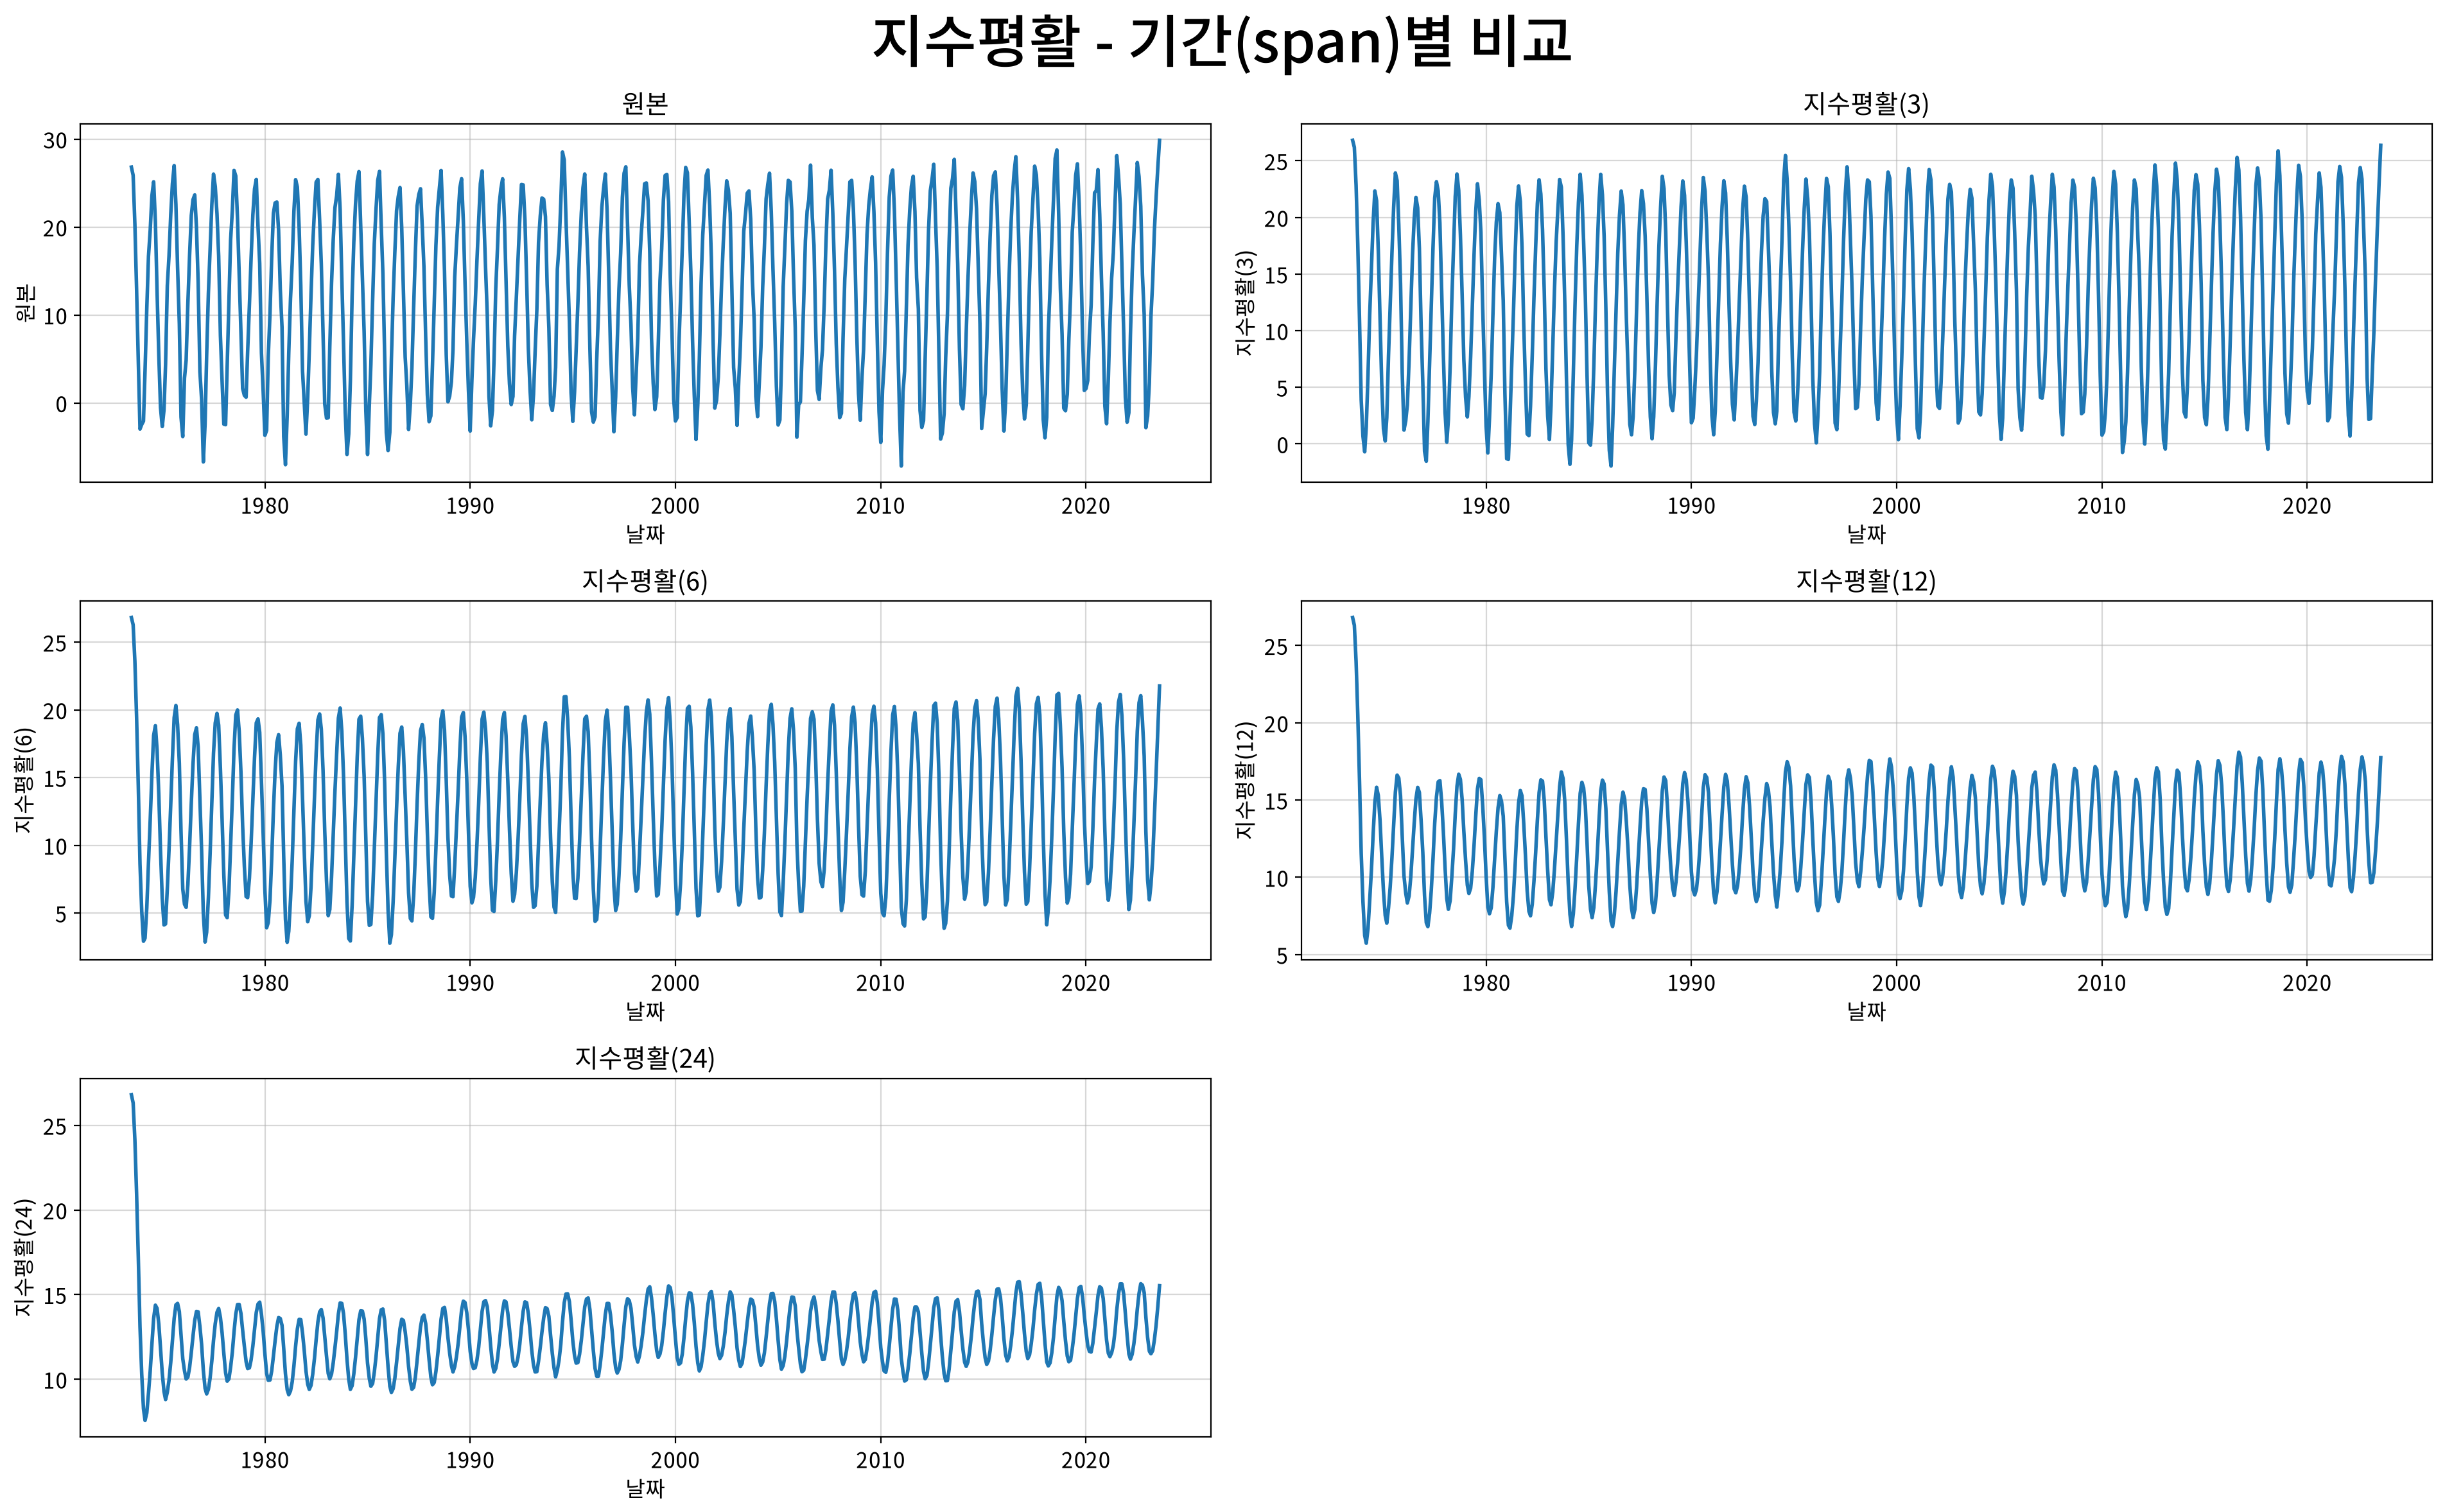

,표준편차
원본,9.932
지수평활(3),7.991
지수평활(6),5.483
지수평활(12),3.251
지수평활(24),1.983


In [72]:
ew = my_ts.compare_smoothing(df, (3, 6, 12, 24), "평균기온(℃)", method="ewm",
                             title="지수평활 - 기간(span)별 비교",
                             width=960, height=400)

ew.std().round(3).to_frame("표준편차")

#### 💡 인사이트

| 기간 | 이동평균 | 지수평활 |
|---|---|---|
| 3 | 8.970 | 7.991 |
| 6 | 6.332 | 5.483 |
| **12** | **0.745** | **3.251** |
| 24 | 0.627 | 1.983 |

기간 3·6에서는 지수평활이 더 매끄럽지만 **12에서 순위가 뒤집힌다.**

★ **지수평활은 최근 값에 큰 가중치를 주므로 현재 계절 쪽으로 끌려간다.**
이동평균은 12개월을 똑같은 비중으로 평균 내므로 계절이 정확히 상쇄된다.

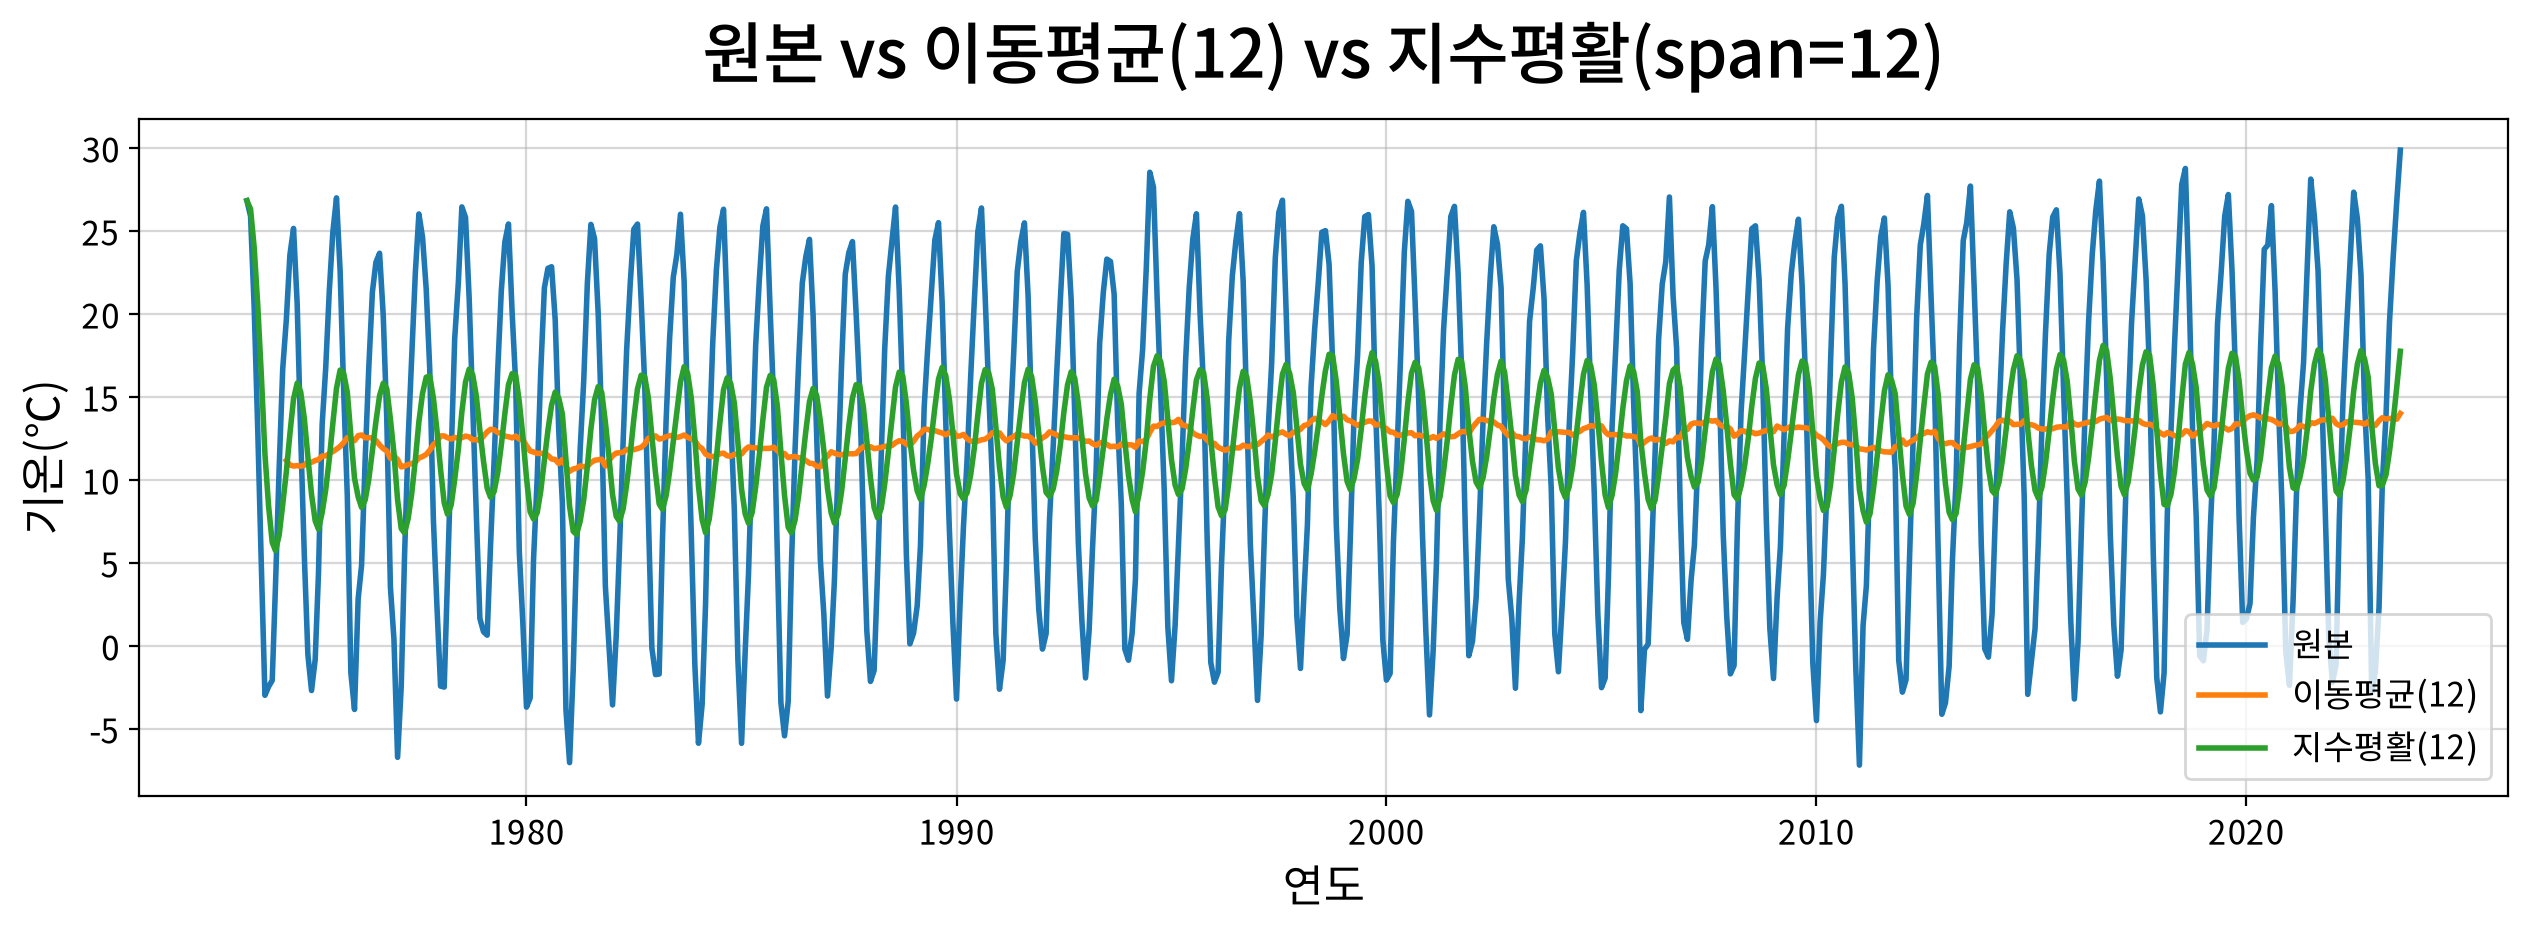

,원본,이동평균(12),지수평활(12)
날짜,,,
2023-06-01,23.383,13.706,13.516
2023-07-01,26.706,13.654,15.545
2023-08-01,29.867,13.997,17.748


In [73]:
both = my_ts.compare_smoothing(df, [12], "평균기온(℃)", method="both", overlay=True,
                               title="원본 vs 이동평균(12) vs 지수평활(span=12)",
                               xlabel="연도", ylabel="기온(℃)",
                               width=1280, height=480)

both.tail(3)

이동평균은 톱니가 사라진 완만한 곡선, 지수평활은 여전히 출렁이며 원본을 뒤쫓는다.

## #05. 최종 확인

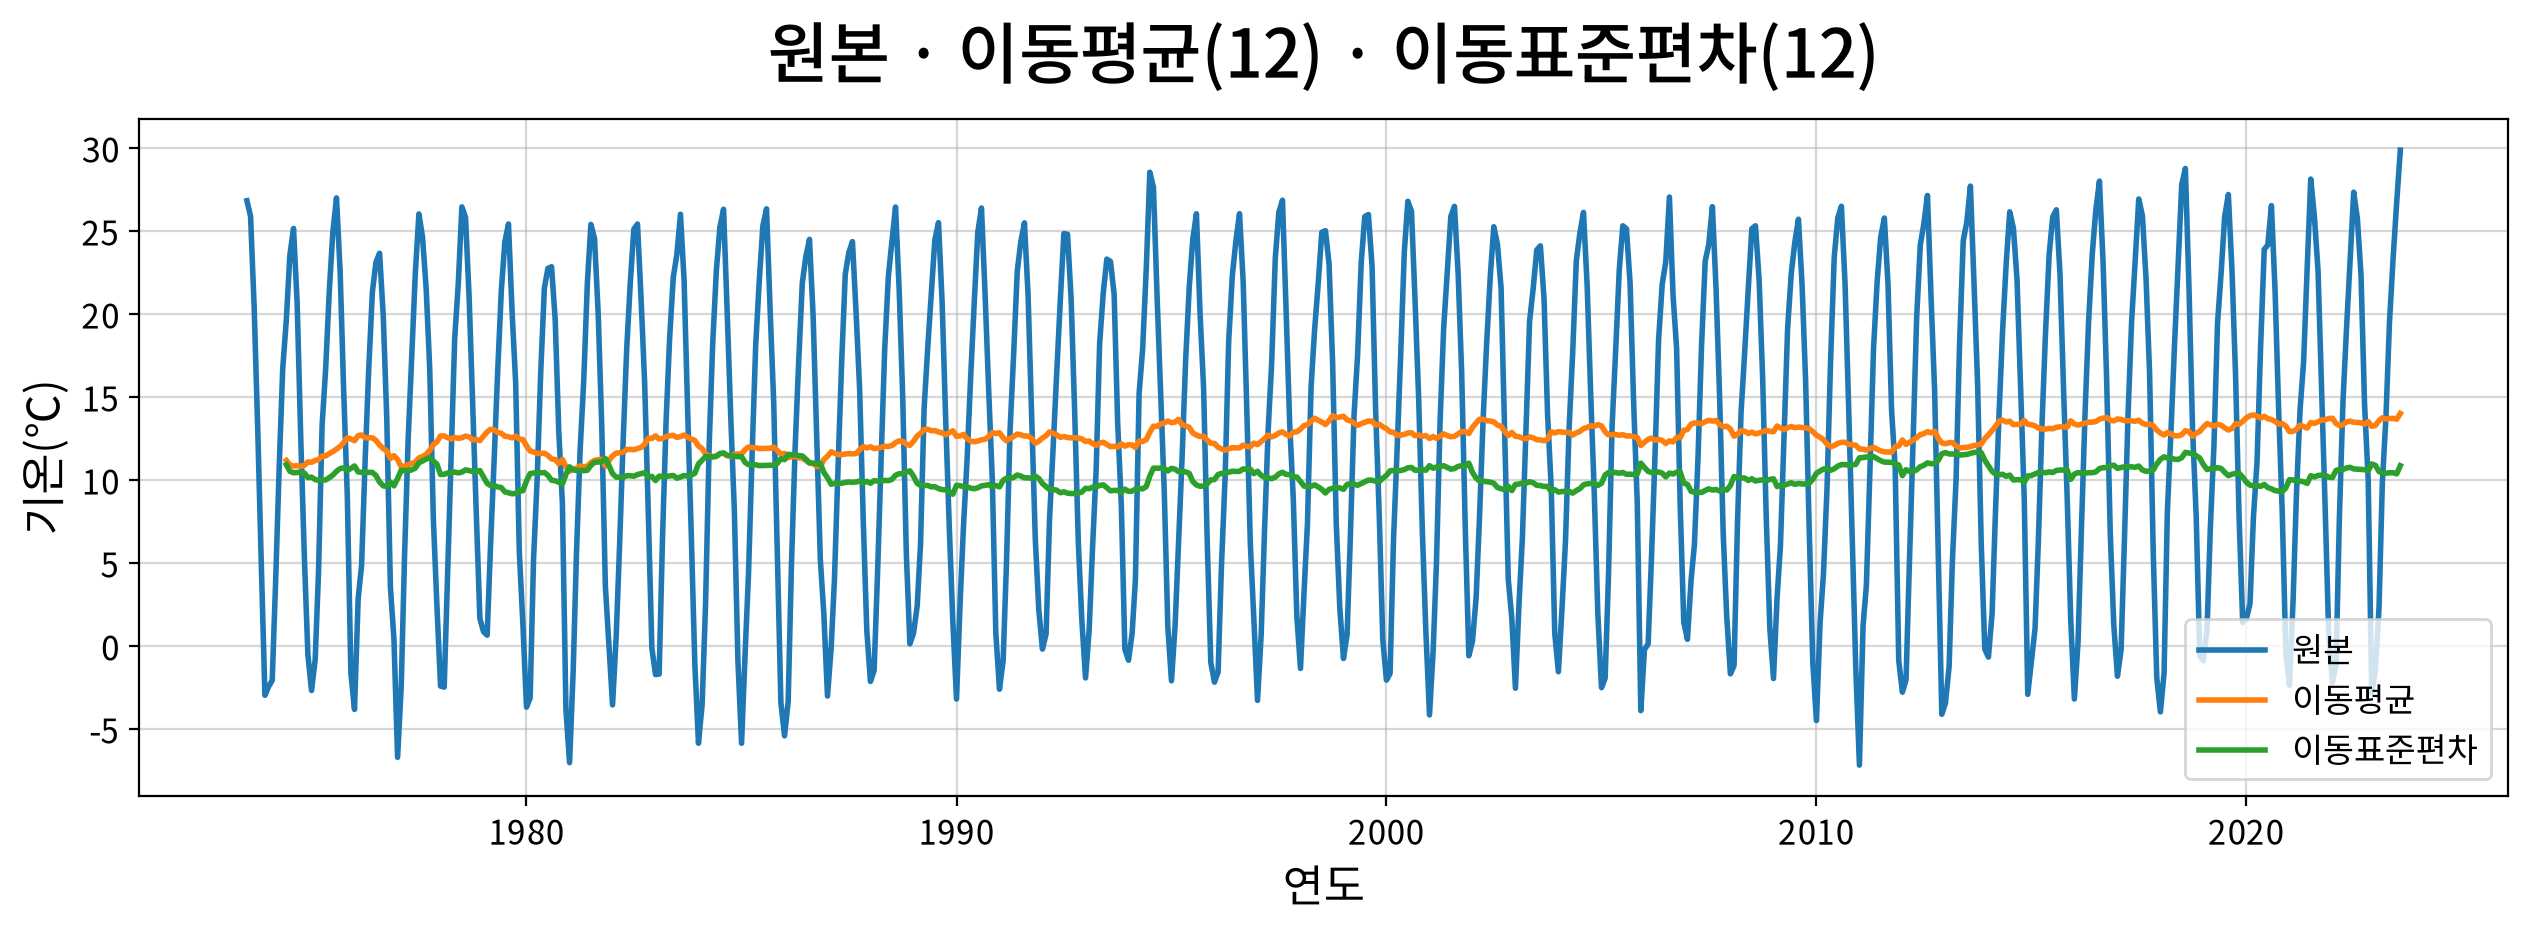

,원본,이동평균,이동표준편차
count,602.000,591.000,591.000
mean,12.614,12.562,10.285
std,9.932,0.745,0.604
min,-7.184,10.515,9.137
25%,3.558,12.053,9.791
50%,13.816,12.637,10.327
75%,21.865,13.167,10.669
max,29.867,13.997,11.667


In [74]:
rolling = my_ts.plot_rolling(df, 12, "평균기온(℃)",
                             title="원본 · 이동평균(12) · 이동표준편차(12)",
                             xlabel="연도", ylabel="기온(℃)",
                             width=1280, height=480)

rolling.describe().round(3)

In [75]:
trend = rolling["이동평균"].dropna()

print(f"시작 {trend.index[0]:%Y-%m}  {trend.iloc[0]:.3f}℃")
print(f"최종 {trend.index[-1]:%Y-%m}  {trend.iloc[-1]:.3f}℃")
print(f"변화 {trend.iloc[-1] - trend.iloc[0]:+.3f}℃")

시작 1974-06  11.168℃
최종 2023-08  13.997℃
변화 +2.830℃


#### 💡 인사이트

원본에서 전혀 보이지 않던 **+2.830℃ 상승**이 드러났다.
이동표준편차가 평평하므로 변동폭은 일정하다 → **로그변환 불필요.**

## #06. 정답

### 1번 — 창 크기 **12**

계절 주기와 같게 잡아야 여름과 겨울이 상쇄되어 계절성이 지워진다.
표준편차 **9.932 → 0.745 (7.5%)**. 창 6은 63.8%가 남아 절반도 못 지운다.
창 24도 지워지지만 결측이 늘어나므로 **가장 작은 창**을 쓴다.

### 2번 — **이동평균**

같은 기간 12에서 **이동평균 0.745 vs 지수평활 3.251 — 4.4배 차이.**
지수평활은 최근 값 가중 때문에 계절의 흔적이 남는다.

> 우열이 아니라 목적의 문제다.
> 장기 추세 → **이동평균(창 = 주기)** / 현재 상태·단기 예측 → **지수평활**

### 3번 — 약 **+2.83℃**

1974-06 **11.168℃** → 2023-08 **13.997℃**

### 반드시 기억할 것

| 원칙 | 내용 |
|---|---|
| 🔑 창 크기는 계절 주기로 | 주기의 배수가 아니면 계절성이 크게 남는다 |
| 🔑 목적이 방법을 정한다 | 장기 추세 → 이동평균 / 현재 상태 → 지수평활 |
| 🔑 가장 작은 창을 쓴다 | 창이 넓을수록 결측이 늘고 최근 변화에 둔해진다 |
| 🔑 평활은 EDA다 | "2.8℃ 상승"은 눈으로 확인한 것이지 검정된 결론이 아니다 |